# DRO Rolling Window Backtest — COLCAP Portfolio Optimization
## Distributionally Robust Optimization con Wasserstein Ambiguity Sets
### Mercado colombiano COLCAP | Validación fuera de muestra con fechas configurables

Este notebook implementa un **rolling window backtest completo** que compara los 6 modelos de optimización de portafolios:

| Modelo | Tipo | ε |
|---|---|---|
| `SAA-Markowitz` | Benchmark | — |
| `MinVar` | Benchmark | — |
| `EqualWeight` | Benchmark | — |
| `2-WDRO-Markowitz` | DRO | ε_max |
| `1-WDRO-CVaR` | DRO | ε_max |
| `2-WDRO-CVaR` | DRO | ε_max |


In [1]:
## ============================================================================
## SECCIÓN 1: IMPORTS Y DEPENDENCIAS
## ============================================================================

import sys
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from datetime import date, datetime
from time import perf_counter
from collections import defaultdict

# Barra de progreso
try:
    from tqdm.notebook import tqdm
    TQDM_AVAILABLE = True
except ImportError:
    TQDM_AVAILABLE = False
    print("  tqdm no disponible - usando print para progreso")

# Widgets interactivos
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    print("  ipywidgets no disponible - usar parámetros por defecto")

# Añadir la carpeta del proyecto al path
PROJECT_ROOT = r"c:\Users\emngz\Downloads\Universidad\P.I,\PI 2"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Módulos DRO del proyecto
from dro_colcap_loader import COLCAPDataLoader
from dro_gurobi_solvers import (
    DROWassersteinMarkowitz,
    DROWassersteinCVaR_1,
    DROWassersteinCVaR_2,
    SAA_Markowitz,
    MinimumVariance,
    EqualWeight,
    compute_mu_max,
    compute_eps_max,
)
from dro_evaluation import PortfolioEvaluator, TurnovoverMetrics

print("✓ Todas las dependencias cargadas correctamente")
print(f"  numpy  : {np.__version__}")
print(f"  pandas : {pd.__version__}")
print(f"  matplotlib: {matplotlib.__version__}")

✓ Todas las dependencias cargadas correctamente
  numpy  : 1.26.0
  pandas : 2.2.2
  matplotlib: 3.8.4


---
## Sección 2: Configuración del Experimento

Aquí defines los parámetros globales del rolling window. Tienes **dos formas** de configurar las fechas:

1. **Parámetros por defecto** (esta celda): modifica las variables directamente
2. **Widgets interactivos** (siguiente celda): usa date pickers visuales para ajustar

### Parámetros de fechas:
- `TRAIN_START_DATE` / `TRAIN_END_DATE`: inicio y fin del **primer** período de entrenamiento
- `VAL_START_DATE` / `VAL_END_DATE`: inicio y fin del período de **validación total** (el rolling window itera sobre este rango)
- `WINDOW_SIZE_DAYS`: tamaño fijo de la ventana de entrenamiento (en días de trading)
- `REBALANCE_FREQ`: frecuencia de rebalanceo en la validación (1 = diario)

In [18]:
## ============================================================================
## SECCION 2A: PARAMETROS POR DEFECTO
## ============================================================================

# --- RUTA DE DATOS -----------------------------------------------------------
DATA_PATH = r"c:\Users\emngz\Downloads\Universidad\P.I,\PI 2\Datos_empresas_colcap_IMPUTADOS"
RESULTS_DIR = Path(PROJECT_ROOT) / "dro_results_rolling"
RESULTS_DIR.mkdir(exist_ok=True)

# --- ARCHIVO BENCHMARK COLCAP (SOLO VISUALIZACION / COMPARACION) ------------
COLCAP_BENCHMARK_CANDIDATES = [
    Path(PROJECT_ROOT) / "COLCAP Historical Data.csv",
 ]
BENCHMARK_LABEL = "COLCAP Index"

# --- CONFIGURACION DEL ROLLING WINDOW ----------------------------------------

# Fecha de inicio y fin del conjunto de ENTRENAMIENTO de la primera ventana
TRAIN_START_DATE  = "2013-01-01"   # fecha de inicio del entrenamiento (primera fecha disponible: 2013-01-01)
TRAIN_END_DATE    = "2020-12-31"   # fecha de fin del entrenamiento

# Fecha de inicio y fin del conjunto de VALIDACION (ventana total de test)
VAL_START_DATE    = "2021-01-01"   # <- Fecha de inicio del test 
VAL_END_DATE      = "2026-02-13"   # <- Fecha final del test (Ultima fecha disponible: 2026-02-13)

# Tamano de la ventana de entrenamiento en dias de trading
WINDOW_SIZE_DAYS  = 252

# Frecuencia de rebalanceo en dias (1 = diario, 5 = semanal, 21 = mensual)
REBALANCE_FREQ    = 1

# --- PARAMETROS DE PORTAFOLIO ------------------------------------------------
SHORT_SELLING     = False          
CVAR_CONFIDENCE   = 0.05           # alpha = 0.05 -> CVaR al 95%
ASSETS_THRESHOLD  = 1e-4           # Umbral minimo para contar un activo como "activo"

MU_OBJETIVO = 0.003  # Legacy (no se usa para target_return)
MU_MAX_FRACTION = 0.75  # target_return = mu_max * MU_MAX_FRACTION por ventana

# Fraccion de epsilon_max a usar para los modelos DRO (calculado dinamicamente c/ ventana)
# NOTA: los epsilon se calculan por ventana adaptandose a los datos.
EPSILON_FRACTIONS = [0.50, 0.75, 1]

# Para mantener compatibilidad con celdas previas
EPSILON_FRACTION = EPSILON_FRACTIONS[0]

# --- MODELOS BASE A INCLUIR ---------------------------------------------------
BASE_MODELS_CONFIG = {
    # (nombre, tipo)
    'SAA-Markowitz'     : 'benchmark',
    'MinVar'            : 'benchmark',
    'EqualWeight'       : 'benchmark',
    '2-WDRO-Markowitz'  : 'dro',
    '1-WDRO-CVaR'       : 'dro',
    '2-WDRO-CVaR'       : 'dro'
}

# --- EXPANSION DE MODELOS POR EPSILON ----------------------------------------
MODEL_RUNS = []
for model_name, model_type in BASE_MODELS_CONFIG.items():
    if model_type == 'dro':
        for eps_frac in EPSILON_FRACTIONS:
            MODEL_RUNS.append({
                'name': f"{model_name} (eps={eps_frac:.2f})",
                'base': model_name,
                'type': model_type,
                'eps_fraction': eps_frac,
            })
    else:
        MODEL_RUNS.append({
            'name': model_name,
            'base': model_name,
            'type': model_type,
            'eps_fraction': None,
        })

MODEL_RUN_NAMES = [m['name'] for m in MODEL_RUNS]
MODEL_RUN_TYPE = {m['name']: m['type'] for m in MODEL_RUNS}
MODEL_RUN_EPS = {m['name']: m['eps_fraction'] for m in MODEL_RUNS}


def get_base_model_name(model_name: str) -> str:
    """Devuelve el nombre base sin el sufijo de epsilon."""
    if " (eps=" in model_name:
        return model_name.split(" (eps=")[0]
    return model_name


print("✓ Parametros por defecto configurados:")
print(f"  Entrenamiento : {TRAIN_START_DATE}  ->  {TRAIN_END_DATE}")
print(f"  Validacion    : {VAL_START_DATE}  ->  {VAL_END_DATE}")
print(f"  Ventana       : {WINDOW_SIZE_DAYS} dias de trading")
print(f"  Rebalanceo    : cada {REBALANCE_FREQ} dia(s)")
print(f"  mu_objetivo   : {(MU_OBJETIVO):.2%} — {(1 + MU_OBJETIVO)**252 - 1:.2%} anualizado (legacy)")
print(f"  mu_max frac   : {MU_MAX_FRACTION:.2%} (target_return = mu_max * frac)")
print(f"  epsilon fracs : {EPSILON_FRACTIONS}")
print(f"  Modelos       : {MODEL_RUN_NAMES}")


✓ Parametros por defecto configurados:
  Entrenamiento : 2013-01-01  ->  2020-12-31
  Validacion    : 2021-01-01  ->  2026-02-13
  Ventana       : 252 dias de trading
  Rebalanceo    : cada 1 dia(s)
  mu_objetivo   : 0.30% — 112.73% anualizado (legacy)
  mu_max frac   : 75.00% (target_return = mu_max * frac)
  epsilon fracs : [0.5, 0.75, 1]
  Modelos       : ['SAA-Markowitz', 'MinVar', 'EqualWeight', '2-WDRO-Markowitz (eps=0.50)', '2-WDRO-Markowitz (eps=0.75)', '2-WDRO-Markowitz (eps=1.00)', '1-WDRO-CVaR (eps=0.50)', '1-WDRO-CVaR (eps=0.75)', '1-WDRO-CVaR (eps=1.00)', '2-WDRO-CVaR (eps=0.50)', '2-WDRO-CVaR (eps=0.75)', '2-WDRO-CVaR (eps=1.00)']


---
## Sección 3: Carga de Datos COLCAP

Cargando datos COLCAP desde: c:\Users\emngz\Downloads\Universidad\P.I,\PI 2\Datos_empresas_colcap_IMPUTADOS
Found 20 CSV files
[OK] Loaded Almacenes Exito: 3199 returns
[OK] Loaded Aval Acciones y Valores Pref: 3199 returns
[OK] Loaded Banco Davivienda Pref: 3199 returns
[OK] Loaded Banco De Bogota: 3199 returns
[OK] Loaded Celsia: 3199 returns
[OK] Loaded Cemargos: 3199 returns
[OK] Loaded Corficol Pref: 3199 returns
[OK] Loaded Corficol: 3199 returns
[OK] Loaded Ecopetrol: 3199 returns
[OK] Loaded Grupo Argos Pref: 3199 returns
[OK] Loaded Grupo Argos: 3199 returns
[OK] Loaded Grupo Bolivar: 3199 returns
[OK] Loaded Grupo Cibest: 3199 returns
[OK] Loaded Grupo de Inversiones Suramericana Pref: 3199 returns
[OK] Loaded Grupo Energia Bogota: 3199 returns
[OK] Loaded ISA Price History: 3199 returns
[OK] Loaded Mineros SA: 3199 returns
[OK] Loaded Organizacion Terpel SA: 3199 returns
[OK] Loaded Promigas: 3199 returns
[OK] Loaded Suramericana: 3199 returns

[INFO] All tickers have identi

,Retorno anual,Volatilidad anual,Sharpe anual,Missing (%)
Ticker,,,,
Almacenes Exito,-0.0679,0.3190,-0.2128,0.0
Aval Acciones y Valores Pref,-0.0365,0.2606,-0.1400,0.0
Banco Davivienda Pref,0.0128,0.2692,0.0476,0.0
Banco De Bogota,-0.0219,0.2721,-0.0804,0.0
Celsia,-0.0038,0.2554,-0.0149,0.0
Cemargos,0.0135,0.3330,0.0404,0.0
Corficol Pref,-0.0331,0.2530,-0.1310,0.0
Corficol,-0.0413,0.2595,-0.1593,0.0
Ecopetrol,-0.0718,0.3552,-0.2022,0.0


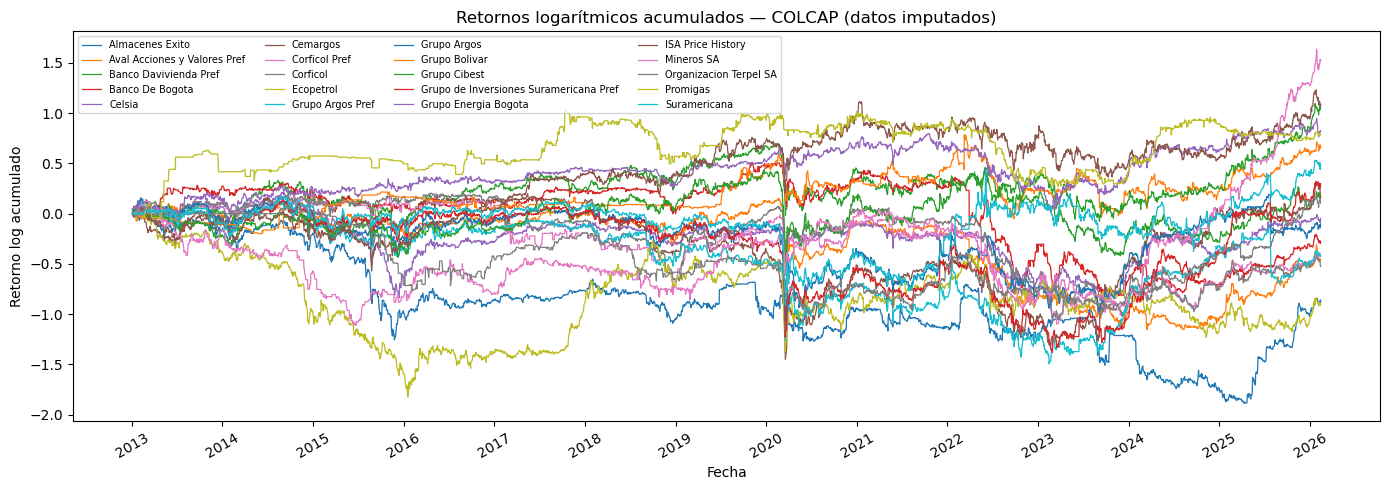

  → Gráfico guardado en c:\Users\emngz\Downloads\Universidad\P.I,\PI 2\dro_results_rolling\0_retornos_acumulados.png

✓ Benchmark cargado desde: COLCAP Historical Data.csv
  Observaciones benchmark (total): 3198
  Observaciones benchmark (validación): 1251
  Nota: el benchmark NO se usa en optimización; solo en comparación visual y métricas.


In [3]:
## ============================================================================
## SECCIÓN 3: CARGA Y PREPARACIÓN DE DATOS
## ============================================================================

print("Cargando datos COLCAP desde:", DATA_PATH)
loader = COLCAPDataLoader(DATA_PATH)
df_combined = loader.load_all_csv()

returns_full  = loader.get_returns()       # (T, m)  — retornos logarítmicos



dates_full    = pd.to_datetime(loader.dates)  # índice temporal
tickers       = loader.get_tickers()

T_total, m = returns_full.shape
print(f"\n  Matriz de retornos global: {T_total} períodos × {m} activos")
print(f"  Rango de fechas          : {dates_full[0].date()} → {dates_full[-1].date()}")
print(f"  Activos                  : {tickers}")

# ─── Estadísticas descriptivas ──────────────────────────────────────────────

mean_ann   = np.mean(returns_full, axis=0) * 252
std_ann    = np.std(returns_full, axis=0) * np.sqrt(252)

desc_df = pd.DataFrame({
    'Ticker'          : tickers,
    'Retorno anual'   : mean_ann.round(4),
    'Volatilidad anual': std_ann.round(4),
    'Sharpe anual'    : (mean_ann / std_ann).round(4),
    'Missing (%)'     : [0.0] * m,   # datos imputados → 0% faltantes
})
print("\n" + "="*70)
print("ESTADÍSTICAS DESCRIPTIVAS (anualizadas, base 252 días)")
print("="*70)
display(desc_df.set_index('Ticker'))

# ─── Plot retornos acumulados ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
cum_ret = np.cumsum(returns_full, axis=0)
for i, t in enumerate(tickers):
    ax.plot(dates_full, cum_ret[:, i], label=t, linewidth=0.9)
ax.set_title("Retornos logarítmicos acumulados — COLCAP (datos imputados)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Retorno log acumulado")
ax.legend(loc='upper left', fontsize=7, ncol=4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "0_retornos_acumulados.png", dpi=150)
plt.show()
print(f"  → Gráfico guardado en {RESULTS_DIR / '0_retornos_acumulados.png'}")

# ─── Carga del benchmark COLCAP (SOLO para gráficas y métricas comparativas) ─
benchmark_path = next((p for p in COLCAP_BENCHMARK_CANDIDATES if p.exists()), None)
benchmark_returns_full = pd.Series(dtype=float)
benchmark_returns_oos = pd.Series(dtype=float)

if benchmark_path is None:
    print("\n⚠️ No se encontró archivo benchmark COLCAP. Se omite comparación en gráficas.")
else:
    benchmark_raw = pd.read_csv(benchmark_path)
    benchmark_raw['Date'] = pd.to_datetime(benchmark_raw['Date'], errors='coerce', format='%m/%d/%Y')
    benchmark_raw['Price'] = (
        benchmark_raw['Price']
        .astype(str)
        .str.replace(',', '', regex=False)
        .astype(float)
    )

    benchmark_raw = benchmark_raw.dropna(subset=['Date', 'Price']).sort_values('Date')
    benchmark_prices = benchmark_raw.set_index('Date')['Price']
    benchmark_returns_full = benchmark_prices.pct_change().dropna()

    val_mask = (dates_full >= pd.Timestamp(VAL_START_DATE)) & (dates_full <= pd.Timestamp(VAL_END_DATE))
    validation_dates = pd.DatetimeIndex(dates_full[val_mask])
    benchmark_returns_oos = benchmark_returns_full.reindex(validation_dates).dropna()

    print(f"\n✓ Benchmark cargado desde: {benchmark_path.name}")
    print(f"  Observaciones benchmark (total): {len(benchmark_returns_full)}")
    print(f"  Observaciones benchmark (validación): {len(benchmark_returns_oos)}")
    print("  Nota: el benchmark NO se usa en optimización; solo en comparación visual y métricas.")

---
## Sección 4: Clase FlexibleRollingWindow y Utilidades

La clase `FlexibleRollingWindow` implementa el rolling window **con especificación exacta de fechas**. Basado en la configuración de la Sección 2, genera iteraciones `(train_returns, val_returns, train_dates, val_dates)`.

### Lógica de ventanas:
```
  |── TRAIN (window_size días) ──|── VAL (rebalance_freq días) ──|
  t=start                      t=t+window_size             t=t+window_size+rebalance_freq
  
  Siguiente iteración:
  |──────── TRAIN (window_size) ────────|── VAL ──|
  t=start+rebalance_freq              ...
```

In [4]:
## ============================================================================
## SECCIÓN 4A: CLASE FlexibleRollingWindow
## ============================================================================

class FlexibleRollingWindow:
    """
    Rolling window con especificación exacta de fechas de entrenamiento y validación.

    Parameters
    ----------
    returns : np.ndarray  (T, m)
        Matriz completa de retornos logarítmicos.
    dates : pd.DatetimeIndex
        Índice temporal, alineado con returns (len == T).
    train_start : str | date
        Fecha de inicio del primer conjunto de entrenamiento.
    train_end : str | date
        Fecha de fin del primer conjunto de entrenamiento.
    val_start : str | date
        Fecha de inicio del período de validación total.
    val_end : str | date
        Fecha de fin del período de validación total.
    window_size : int
        Número de días de trading en la ventana de entrenamiento (ventana deslizante).
    rebalance_freq : int
        Número de días de trading entre rebalanceos (paso del rolling window).
    """

    def __init__(
        self,
        returns: np.ndarray,
        dates: pd.DatetimeIndex,
        train_start: str,
        train_end: str,
        val_start: str,
        val_end: str,
        window_size: int,
        rebalance_freq: int,
    ):
        self.returns       = returns
        self.dates         = pd.to_datetime(dates)
        self.window_size   = window_size
        self.rebalance_freq = rebalance_freq

        # Convertir fechas a pd.Timestamp para comparaciones
        self.train_start = pd.Timestamp(train_start)
        self.train_end   = pd.Timestamp(train_end)
        self.val_start   = pd.Timestamp(val_start)
        self.val_end     = pd.Timestamp(val_end)

        # Índices enteros en el arreglo de retornos
        self._train_start_idx = self._date_to_idx(self.train_start, side='left')
        self._train_end_idx   = self._date_to_idx(self.train_end,   side='right')
        self._val_start_idx   = self._date_to_idx(self.val_start,   side='left')
        self._val_end_idx     = self._date_to_idx(self.val_end,     side='right')

        self._validate()

    def _date_to_idx(self, target: pd.Timestamp, side: str = 'left') -> int:
        """Retorna el índice entero más cercano a target en self.dates."""
        idx_array = self.dates.searchsorted(target, side=side)
        return int(np.clip(idx_array, 0, len(self.dates) - 1))

    def _validate(self):
        """Verifica que los rangos de fecha sean consistentes con los datos."""
        T = len(self.returns)
        assert self._train_start_idx < self._train_end_idx, (
            f"train_start ({self.train_start.date()}) debe ser anterior a train_end ({self.train_end.date()})")
        assert self._val_start_idx < self._val_end_idx, (
            f"val_start ({self.val_start.date()}) debe ser anterior a val_end ({self.val_end.date()})")
        assert self._train_end_idx <= self._val_start_idx, (
            "El período de entrenamiento inicial debe terminar antes de que empiece la validación.")
        avail_train = self._train_end_idx - self._train_start_idx
        assert avail_train >= self.window_size, (
            f"Rango de entrenamiento ({avail_train} días) < window_size ({self.window_size}). "
            "Amplía el rango de fechas de entrenamiento.")
        print(f"  ✓ Ventana inicial de entrenamiento  : {self.dates[self._train_start_idx].date()} → "
              f"{self.dates[self._train_end_idx - 1].date()} ({avail_train} días)")
        print(f"  ✓ Período de validación completo    : {self.dates[self._val_start_idx].date()} → "
              f"{self.dates[self._val_end_idx - 1].date()} "
              f"({self._val_end_idx - self._val_start_idx} días)")

    def generate(self):
        """
        Genera tuplas (train_ret, val_ret, train_dates, val_dates, window_idx).

        La ventana de entrenamiento queda anclada al fin real del entrenamiento
        (TRAIN_END_DATE) y la de validación al inicio real de validación
        (VAL_START_DATE). Si hay un hueco entre ambas fechas, ese hueco no entra
        al entrenamiento ni a la validación.
        """
        step = 0

        while True:
            val_blk_start = self._val_start_idx + step * self.rebalance_freq

            if val_blk_start >= self._val_end_idx:
                break

            val_blk_end = min(val_blk_start + self.rebalance_freq, self._val_end_idx)

            train_blk_end = self._train_end_idx + step * self.rebalance_freq
            train_blk_start = train_blk_end - self.window_size

            if train_blk_start < self._train_start_idx:
                step += 1
                continue

            if train_blk_end > len(self.returns):
                break

            train_ret = self.returns[train_blk_start:train_blk_end]
            val_ret = self.returns[val_blk_start:val_blk_end]
            train_dates = self.dates[train_blk_start:train_blk_end]
            val_dates = self.dates[val_blk_start:val_blk_end]

            yield train_ret, val_ret, train_dates, val_dates, step
            step += 1

    def num_iterations(self) -> int:
        """Número total de iteraciones del rolling window."""
        val_days = self._val_end_idx - self._val_start_idx
        return max(0, (val_days + self.rebalance_freq - 1) // self.rebalance_freq)


print("✓ Clase FlexibleRollingWindow definida")

✓ Clase FlexibleRollingWindow definida


In [5]:
## ============================================================================
## SECCION 4B: FUNCION SOLUCIONADORA — UNA ITERACION DEL ROLLING WINDOW
## ============================================================================

def solve_one_window(
    train_ret: np.ndarray,
    mu_objetivo: float,
    epsilon_fraction: float,
    short_selling: bool,
    cvar_alpha: float,
    ) -> Dict:
    """
    Dado un conjunto de retornos de entrenamiento, resuelve todos los modelos.

    ========================================
    La restriccion de retorno robusto es:
        w^T mu >= target_return
    
    donde:
    - mu es el vector de retornos esperados (estimado desde train_ret)
    - target_return = mu_max * MU_MAX_FRACTION (calculado por ventana)
    - mu_objetivo se mantiene solo por compatibilidad (no se usa)
    
    Parametros DINAMICOS (adaptativos por ventana, siguiendo la teoria):
        eps_max -> formula cerrada (Fonseca & Junca, 2021)
        epsilon = epsilon_fraction * eps_max
    
    Parameters
    ----------
    train_ret : np.ndarray
        Matriz de retornos del conjunto de entrenamiento (T_train, m)
    mu_objetivo : float
        Legacy (se conserva por compatibilidad de llamadas)
    epsilon_fraction : float
        Fraccion de epsilon_max a usar
    short_selling : bool
        Si permite ventas en corto
    cvar_alpha : float
        Nivel de confianza para CVaR
    
    Returns
    -------
    dict : {model_name: {'weights': np.ndarray, 'status': str, ...}}
    """
    results = {}
    timing = {}

    t_window_start = perf_counter()

    # ── Estadisticos del conjunto de entrenamiento ───────────────────────────
    mean = np.mean(train_ret, axis=0)
    cov  = (train_ret - mean).T @ (train_ret - mean) / len(train_ret)

    # ── Calcular mu_max (heuristico existente) ───────────────────────────────
    t0 = perf_counter()
    try:
        mu_max = compute_mu_max(train_ret)
    except Exception:
        mu_max = float(np.max(mean))
    timing['compute_mu_max'] = perf_counter() - t0

    # target_return derivado de mu_max (override siempre)
    target_return = mu_max * MU_MAX_FRACTION
    
    if target_return > mu_max:
        print(
            f"    WARNING: target_return ({target_return:.6f}) > mu_max ({mu_max:.6f}). ",
            "Verifica MU_MAX_FRACTION."
        )

    # ── Calcular epsilon_max usando target_return ────────────────────────────
    t0 = perf_counter()
    try:
        eps_max = compute_eps_max(train_ret, target_return)
    except Exception:
        eps_max = 1e-4
    timing['compute_eps_max'] = perf_counter() - t0

    epsilon = epsilon_fraction * eps_max

    # ── 2-WDRO-Markowitz ─────────────────────────────────────────────────────
    t0 = perf_counter()
    try:
        mdl = DROWassersteinMarkowitz(mean, cov, epsilon, target_return,
                                      short_selling=short_selling)
        res = mdl.solve()
        results['2-WDRO-Markowitz'] = res | {
            'mu_max': mu_max,
            'eps_max': eps_max,
            'epsilon': epsilon,
            'target_return': target_return,
        }
    except Exception as e:
        results['2-WDRO-Markowitz'] = {
            'status': 'error',
            'error': str(e),
            'target_return': target_return,
        }
    timing['2-WDRO-Markowitz'] = perf_counter() - t0

    # ── 1-WDRO-CVaR ──────────────────────────────────────────────────────────
    t0 = perf_counter()
    try:
        mdl = DROWassersteinCVaR_1(train_ret, epsilon, target_return,
                                   confidence_level=cvar_alpha,
                                   short_selling=short_selling)
        res = mdl.solve()
        results['1-WDRO-CVaR'] = res | {
            'mu_max': mu_max,
            'eps_max': eps_max,
            'epsilon': epsilon,
            'target_return': target_return,
        }
    except Exception as e:
        results['1-WDRO-CVaR'] = {
            'status': 'error',
            'error': str(e),
            'target_return': target_return,
        }
    timing['1-WDRO-CVaR'] = perf_counter() - t0

    # ── 2-WDRO-CVaR ──────────────────────────────────────────────────────────
    t0 = perf_counter()
    try:
        mdl = DROWassersteinCVaR_2(train_ret, epsilon, target_return,
                                   confidence_level=cvar_alpha,
                                   short_selling=short_selling)
        res = mdl.solve()
        results['2-WDRO-CVaR'] = res | {
            'mu_max': mu_max,
            'eps_max': eps_max,
            'epsilon': epsilon,
            'target_return': target_return,
        }
    except Exception as e:
        results['2-WDRO-CVaR'] = {
            'status': 'error',
            'error': str(e),
            'target_return': target_return,
        }
    timing['2-WDRO-CVaR'] = perf_counter() - t0

    # ── SAA-Markowitz (epsilon = 0) ──────────────────────────────────────────
    t0 = perf_counter()
    try:
        mdl = SAA_Markowitz(mean, cov, target_return, short_selling=short_selling)
        res = mdl.solve()
        results['SAA-Markowitz'] = res | {
            'mu_max': mu_max,
            'eps_max': eps_max,
            'epsilon': 0.0,
            'target_return': target_return,
        }
    except Exception as e:
        results['SAA-Markowitz'] = {
            'status': 'error',
            'error': str(e),
            'target_return': target_return,
        }
    timing['SAA-Markowitz'] = perf_counter() - t0

    # ── MinVar ───────────────────────────────────────────────────────────────
    t0 = perf_counter()
    try:
        mdl = MinimumVariance(cov, short_selling=short_selling)
        res = mdl.solve()
        results['MinVar'] = res | {
            'mu_max': mu_max,
            'eps_max': eps_max,
            'epsilon': 0.0,
            'target_return': target_return,
        }
    except Exception as e:
        results['MinVar'] = {
            'status': 'error',
            'error': str(e),
            'target_return': target_return,
        }
    timing['MinVar'] = perf_counter() - t0

    # ── EqualWeight ──────────────────────────────────────────────────────────
    t0 = perf_counter()
    mdl = EqualWeight(m)
    res = mdl.solve()
    results['EqualWeight'] = res | {
        'mu_max': mu_max,
        'eps_max': eps_max,
        'epsilon': 0.0,
        'target_return': target_return,
        'expected_return': float(mean @ res['weights']),
        'std_dev': float(np.sqrt(res['weights'] @ cov @ res['weights'])),
    }
    timing['EqualWeight'] = perf_counter() - t0

    timing['window_total'] = perf_counter() - t_window_start
    results['_timing'] = timing

    return results


print("✓ Funcion solve_one_window definida (target_return desde mu_max)")


✓ Funcion solve_one_window definida (target_return desde mu_max)


---
## Sección 5: Ejecución del Rolling Window Backtest

Esta es la celda principal de cómputo. Para cada ventana del rolling window:

1. Resuelve los 6 modelos sobre datos de **entrenamiento** con hiperparámetros dinámicos
2. Aplica los pesos óptimos al período de **validación** calculando retornos de portafolio
3. Guarda pesos, retornos de validación y metadatos

> ⏱️ Esta celda puede tardar varios minutos dependiendo del número de iteraciones y modelos.

In [6]:
## ============================================================================
## SECCION 5: EJECUCION DEL ROLLING WINDOW BACKTEST
## ============================================================================

print("="*70)
print(" ROLLING WINDOW BACKTEST — DRO COLCAP")
print("="*70)

# ── Instanciar rolling window ─────────────────────────────────────────────────
rw = FlexibleRollingWindow(
    returns       = returns_full,
    dates         = dates_full,
    train_start   = TRAIN_START_DATE,
    train_end     = TRAIN_END_DATE,
    val_start     = VAL_START_DATE,
    val_end       = VAL_END_DATE,
    window_size   = WINDOW_SIZE_DAYS,
    rebalance_freq= REBALANCE_FREQ,
 )

n_iters = rw.num_iterations()
print(f"\n  Total de iteraciones estimadas : {n_iters}")
print(f"  Modelos por iteracion          : {len(MODEL_RUN_NAMES)}")
print(f"  Activos (m)                    : {m}")
print(f"  mu_max frac                    : {MU_MAX_FRACTION:.2%} (target_return = mu_max * frac)")
print(f"  epsilon fracs                  : {EPSILON_FRACTIONS}")
print()

# ── Estructuras para almacenar resultados ─────────────────────────────────────
# raw_results[modelo] = lista de dicts por iteracion
raw_results: Dict[str, List[Dict]] = defaultdict(list)

# Barra de progreso
iterator = rw.generate()
if TQDM_AVAILABLE:
    iterator = tqdm(rw.generate(), total=n_iters, desc="Rolling Window")

# ── Loop principal ─────────────────────────────────────────────────────────────
for train_ret, val_ret, train_dates, val_dates, step_idx in iterator:
    for eps_idx, eps_frac in enumerate(EPSILON_FRACTIONS):
        # Resolver todos los modelos en esta ventana de entrenamiento
        window_results = solve_one_window(
            train_ret        = train_ret,
            mu_objetivo      = MU_OBJETIVO,
            epsilon_fraction = eps_frac,
            short_selling    = SHORT_SELLING,
            cvar_alpha       = CVAR_CONFIDENCE,
            
        )

        timing = window_results.get('_timing', {})
        print(
            f"[iter {step_idx:03d} | eps={eps_frac:.2f}] "
            f"mu_max={timing.get('compute_mu_max', np.nan):7.3f}s | "
            f"eps_max={timing.get('compute_eps_max', np.nan):7.3f}s | "
            f"SAA={timing.get('SAA-Markowitz', np.nan):7.3f}s | "
            f"MinVar={timing.get('MinVar', np.nan):7.3f}s | "
            f"EqW={timing.get('EqualWeight', np.nan):7.3f}s | "
            f"2W-Mkv={timing.get('2-WDRO-Markowitz', np.nan):7.3f}s | "
            f"1W-CVaR={timing.get('1-WDRO-CVaR', np.nan):7.3f}s | "
            f"2W-CVaR={timing.get('2-WDRO-CVaR', np.nan):7.3f}s | "
            f"total={timing.get('window_total', np.nan):7.3f}s"
        )

        # Para cada modelo base, guardar resultados
        for model_name, model_type in BASE_MODELS_CONFIG.items():
            # Evitar duplicar benchmarks para cada epsilon
            if model_type != 'dro' and eps_idx > 0:
                continue

            run_name = model_name if model_type != 'dro' else f"{model_name} (eps={eps_frac:.2f})"
            res = window_results.get(model_name, {})

            if res.get('status') != 'optimal':
                # Modelo fallo -> guardar registro de infactibilidad o error
                raw_results[run_name].append({
                    'step'         : step_idx,
                    'val_start'    : val_dates[0] if len(val_dates) else pd.NaT,
                    'val_end'      : val_dates[-1] if len(val_dates) else pd.NaT,
                    'weights'      : np.full(m, np.nan),
                    'val_returns'  : np.full(len(val_ret), np.nan),
                    'mu_max'       : res.get('mu_max', np.nan),
                    'eps_max'      : res.get('eps_max', np.nan),
                    'epsilon'      : res.get('epsilon', np.nan),
                    'target_return': res.get('target_return', np.nan),
                    'epsilon_fraction': eps_frac if model_type == 'dro' else None,
                    'status'       : res.get('status', 'unknown'),
                    'status_code'  : res.get('status_code', -1),
                    'status_description': res.get('status_description', 'desconocido'),
                })
                continue

            weights     = res['weights']
            port_ret    = val_ret @ weights          # retornos del portafolio en validacion

            raw_results[run_name].append({
                'step'         : step_idx,
                'val_start'    : val_dates[0],
                'val_end'      : val_dates[-1],
                'weights'      : weights.copy(),
                'val_returns'  : port_ret.copy(),
                'mu_max'       : res.get('mu_max', np.nan),
                'eps_max'      : res.get('eps_max', np.nan),
                'epsilon'      : res.get('epsilon', np.nan),
                'target_return': res.get('target_return', np.nan),
                'epsilon_fraction': eps_frac if model_type == 'dro' else None,
                'status'       : res.get('status', 'optimal'),
                'status_code'  : res.get('status_code', 2),
                'status_description': res.get('status_description', 'Solucion optima'),
            })

print("\n✅ Backtest completado!")
print(f"  Iteraciones ejecutadas: {step_idx + 1}")

# Log detallado de tasas de exito por modelo
print("\n  📊 Estadisticas por modelo:")
for model_name in MODEL_RUN_NAMES:
    entries = raw_results.get(model_name, [])
    if not entries:
        continue
    optimal = sum(1 for e in entries if e['status'] == 'optimal')

    # Agrupar todos los NO-optimos por tipo de estado
    non_optimal = [e for e in entries if e['status'] != 'optimal']

    print(f"\n    {model_name}:")
    print(f"      ✓ Optimo            : {optimal}/{len(entries)}")

    if non_optimal:
        # Contar por tipo de estado
        from collections import Counter
        status_counts = Counter(e['status'] for e in non_optimal)

        for status, count in sorted(status_counts.items(), key=lambda x: -x[1]):
            # Obtener descripcion de uno de los ejemplos
            example = next((e for e in non_optimal if e['status'] == status), None)
            description = example['status_description'] if example else status
            print(f"      ✗ {status:<20}: {count:3d} | {description}")


 ROLLING WINDOW BACKTEST — DRO COLCAP
  ✓ Ventana inicial de entrenamiento  : 2013-01-03 → 2020-12-31 (1948 días)
  ✓ Período de validación completo    : 2021-01-04 → 2026-02-12 (1250 días)

  Total de iteraciones estimadas : 1250
  Modelos por iteracion          : 12
  Activos (m)                    : 20
  mu_max frac                    : 75.00% (target_return = mu_max * frac)
  epsilon fracs                  : [0.5, 0.75, 1]



Rolling Window:   0%|          | 0/1250 [00:00<?, ?it/s]

Set parameter Username
Set parameter LicenseID to value 2782388
Academic license - for non-commercial use only - expires 2027-02-23


[iter 000 | eps=0.50] mu_max=  0.063s | eps_max=  0.000s | SAA=  0.023s | MinVar=  0.014s | EqW=  0.000s | 2W-Mkv=  0.127s | 1W-CVaR=  0.053s | 2W-CVaR=  2.185s | total=  2.467s
[iter 000 | eps=0.75] mu_max=  0.002s | eps_max=  0.000s | SAA=  0.013s | MinVar=  0.011s | EqW=  0.000s | 2W-Mkv=  0.016s | 1W-CVaR=  0.279s | 2W-CVaR=  1.945s | total=  2.267s
[iter 000 | eps=1.00] mu_max=  0.001s | eps_max=  0.000s | SAA=  0.013s | MinVar=  0.012s | EqW=  0.000s | 2W-Mkv=  0.011s | 1W-CVaR=  0.044s | 2W-CVaR=  0.147s | total=  0.229s
[iter 001 | eps=0.50] mu_max=  0.002s | eps_max=  0.000s | SAA=  0.010s | MinVar=  0.010s | EqW=  0.000s | 2W-Mkv=  0.014s | 1W-CVaR=  0.049s | 2W-CVaR=  1.144s | total=  1.230s
[iter 001 | eps=0.75] mu_max=  0.001s | eps_max=  0.000s | SAA=  0.011s | MinVar=  0.009s | EqW=  0.000s | 2W-Mkv=  0.013s | 1W-CVaR=  0.082s | 2W-CVaR=  0.127s | total=  0.243s
[iter 001 | eps=1.00] mu_max=  0.001s | eps_max=  0.000s | SAA=  0.011s | MinVar=  0.009s | EqW=  0.000s | 2W-

---
## Sección 5B: Análisis Detallado de Errores por Modelo

Desglose de qué tipos de errores provocó cada modelo durante el backtest, con causas específicas de Gurobi:
- `time_limit`: El solver alcanzó el límite de tiempo sin encontrar solución óptima
- `numeric`: Problemas numéricos en la matriz (singularidad, mal condicionamiento)
- `infeasible`: No existe solución factible dadas las restricciones
- `unbounded`: El problema no tiene límite inferior (objetivo → -∞)
- Otros: Estados específicos del solver Gurobi


In [7]:
## ============================================================================
## SECCIÓN 5B: ANÁLISIS DETALLADO DE ERRORES POR MODELO
## ============================================================================

from collections import Counter

print("\n" + "="*80)
print("  ANÁLISIS DETALLADO: CAUSAS DE ERRORES POR MODELO")
print("="*80)

for model_name in MODEL_RUN_NAMES:
    entries = raw_results.get(model_name, [])
    if len(entries) == 0:
        print(f"\n  ℹ️  {model_name}: SIN EJECUCIONES")
        continue

    non_optimal = [e for e in entries if e.get('status') != 'optimal']
    n_non = len(non_optimal)
    n_total = len(entries)
    pct = 100.0 * n_non / n_total if n_total > 0 else 0.0

    if n_non == 0:
        print(f"\n  ✓ {model_name}: SIN ERRORES ({n_total}/{n_total} óptimas)")
        continue

    print(f"\n  ⚠️  {model_name}: {n_non}/{n_total} errores ({pct:.1f}%)")

    status_counts = Counter(e.get('status', 'unknown') for e in non_optimal)
    for status, count in sorted(status_counts.items(), key=lambda x: -x[1]):
        example = next((e for e in non_optimal if e.get('status') == status), None)
        description = example.get('status_description', status) if example else status
        solve_time = example.get('solve_time') if example and 'solve_time' in example else None
        solve_time_str = f" | solve_time={solve_time:.3f}s" if solve_time is not None else ""
        print(f"     └─ {status:<20} ({count:3d}): {description}{solve_time_str}")



  ANÁLISIS DETALLADO: CAUSAS DE ERRORES POR MODELO

  ⚠️  SAA-Markowitz: 28/1250 errores (2.2%)
     └─ failed               ( 28): desconocido

  ✓ MinVar: SIN ERRORES (1250/1250 óptimas)

  ✓ EqualWeight: SIN ERRORES (1250/1250 óptimas)

  ⚠️  2-WDRO-Markowitz (eps=0.50): 28/1250 errores (2.2%)
     └─ infeasible           ( 28): infeasible

  ⚠️  2-WDRO-Markowitz (eps=0.75): 28/1250 errores (2.2%)
     └─ infeasible           ( 28): infeasible

  ⚠️  2-WDRO-Markowitz (eps=1.00): 28/1250 errores (2.2%)
     └─ infeasible           ( 28): infeasible

  ⚠️  1-WDRO-CVaR (eps=0.50): 28/1250 errores (2.2%)
     └─ inf_or_unbd          ( 28): inf_or_unbd

  ⚠️  1-WDRO-CVaR (eps=0.75): 28/1250 errores (2.2%)
     └─ inf_or_unbd          ( 28): inf_or_unbd

  ⚠️  1-WDRO-CVaR (eps=1.00): 28/1250 errores (2.2%)
     └─ inf_or_unbd          ( 28): inf_or_unbd

  ⚠️  2-WDRO-CVaR (eps=0.50): 28/1250 errores (2.2%)
     └─ infeasible           ( 28): infeasible

  ⚠️  2-WDRO-CVaR (eps=0.75): 28/1

---
## Sección 6: Cálculo de Métricas de Validación

Para cada modelo calculamos las siguientes métricas sobre los **datos de validación**:

| Métrica | Descripción |
|---|---|
| **Media** | $\bar{r} = \frac{1}{T_{val}} \sum_t r_t^{(w)}$ |
| **Std** | $\sigma = \sqrt{\frac{1}{T_{val}} \sum_t (r_t^{(w)} - \bar{r})^2}$ |
| **Sharpe** | $SR = \bar{r} / \sigma$ (diario; para anualizar: $\times \sqrt{252}$) |
| **CVaR(0.05)** | $\text{CVaR}_{0.05} = E[r \mid r \leq \text{VaR}_{0.05}]$ |
| **Avg. Portfolio Assets** | $\bar{A} = \frac{1}{T_r}\sum_t \sum_i \mathbf{1}[w_{t,i} > 10^{-4}]$ |
| **Turnover** | $ TO = \frac{1}{T_r-1}\sum_{t=1}^{T_r-1} \frac{1}{2}\sum_i |w_{t,i} - w_{t-1,i}|$ |

In [8]:
## ============================================================================
## SECCIÓN 6: CÁLCULO DE MÉTRICAS DE VALIDACIÓN
## ============================================================================

def compute_rolling_metrics(raw_results: Dict, assets_threshold: float, cvar_alpha: float) -> pd.DataFrame:
    """
    Calcula las métricas comparativas por modelo sobre los datos de validación.

    Returns
    -------
    pd.DataFrame
        Una fila por modelo con: Media, Std, Sharpe (diario y anualizado),
        CVaR(alpha), Turnover promedio, Avg. Portfolio Assets.
    """
    evaluator = PortfolioEvaluator()
    rows = []

    for model_name in MODEL_RUN_NAMES:
        entries = raw_results.get(model_name, [])
        ok_entries = [e for e in entries if e['status'] == 'optimal'
                      and not np.any(np.isnan(e['val_returns']))]

        if not ok_entries:
            rows.append({'Model': model_name,
                         'Tipo': MODEL_RUN_TYPE.get(model_name, 'unknown').upper(),
                         'Epsilon frac': MODEL_RUN_EPS.get(model_name, np.nan),
                         'Media': np.nan, 'Std': np.nan,
                         'Sharpe (diario)': np.nan, 'Sharpe (anual)': np.nan,
                         'CVaR(0.05)': np.nan, 'Turnover': np.nan,
                         'Avg. Portfolio Assets': np.nan,
                         'Target return (prom)': np.nan,
                         'Delta TR - Media': np.nan,
                         'N iteraciones OK': 0})
            continue

        # ─ Concatenar todos los retornos de validación ──────────────────────
        all_val_returns = np.concatenate([e['val_returns'] for e in ok_entries])

        # ─ Métricas sobre retornos concatenados ─────────────────────────────
        media  = float(np.mean(all_val_returns))
        std    = float(np.std(all_val_returns, ddof=1))
        sharpe = media / std if std > 0 else np.nan
        sharpe_ann = sharpe * np.sqrt(252)

        # CVaR(α): media de pérdidas por debajo del percentil α
        var_alpha   = np.percentile(all_val_returns, cvar_alpha * 100)
        cvar_val    = float(np.mean(all_val_returns[all_val_returns <= var_alpha]))

        # ─ Turnover ──────────────────────────────────────────────────────────
        weights_seq = [e['weights'] for e in ok_entries]  # lista de arrays (m,)
        if len(weights_seq) >= 2:
            turnovers = TurnovoverMetrics.compute_turnover(np.array(weights_seq))
            avg_turnover = float(np.mean(turnovers))
        else:
            avg_turnover = np.nan

        # ─ Avg. Portfolio Assets ──────────────────────────────────────────────
        n_assets_per_iter = [
            int(np.sum(e['weights'] > assets_threshold))
            for e in ok_entries
        ]
        avg_assets = float(np.mean(n_assets_per_iter))

        # ─ Promedio por ventana del target_return (mu_max * MU_MAX_FRACTION) ──
        target_returns = [e.get('target_return', np.nan) for e in ok_entries]
        target_return_avg = float(np.nanmean(target_returns)) if target_returns else np.nan
        if np.isnan(target_return_avg):
            delta_tr_media = np.nan
        else:
            delta_tr_media = float(target_return_avg - media)

        rows.append({
            'Model'                : model_name,
            'Tipo'                 : MODEL_RUN_TYPE.get(model_name, 'unknown').upper(),
            'Epsilon frac'         : MODEL_RUN_EPS.get(model_name, np.nan),
            'Media'                : round(media, 7),
            'Std'                  : round(std, 7),
            'Sharpe (diario)'      : round(sharpe, 4),
            'Sharpe (anual)'       : round(sharpe_ann, 4),
            'CVaR(0.05)'           : round(cvar_val, 6),
            'Turnover'             : round(avg_turnover, 4) if not np.isnan(avg_turnover) else np.nan,
            'Avg. Portfolio Assets': round(avg_assets, 2),
            'Target return (prom)' : round(target_return_avg, 7) if not np.isnan(target_return_avg) else np.nan,
            'Delta TR - Media'     : round(delta_tr_media, 7) if not np.isnan(delta_tr_media) else np.nan,
            'N iteraciones OK'     : len(ok_entries),
        })

    return pd.DataFrame(rows).set_index('Model')


metrics_df = compute_rolling_metrics(raw_results, ASSETS_THRESHOLD, CVAR_CONFIDENCE)

# Métricas del benchmark externo (solo comparación, no optimización)
if 'benchmark_returns_oos' in globals() and len(benchmark_returns_oos) > 0:
    _bench = benchmark_returns_oos.values
    _media = float(np.mean(_bench))
    _std = float(np.std(_bench, ddof=0))
    _sharpe = _media / _std if _std > 0 else np.nan
    _var_alpha = np.percentile(_bench, CVAR_CONFIDENCE * 100)
    _cvar = float(np.mean(_bench[_bench <= _var_alpha]))

    metrics_df.loc[BENCHMARK_LABEL, :] = {
        'Tipo': 'BENCHMARK',
        'Epsilon frac': np.nan,
        'Media': round(_media, 7),
        'Std': round(_std, 7),
        'Sharpe (diario)': round(_sharpe, 4),
        'Sharpe (anual)': round(_sharpe * np.sqrt(252), 4),
        'CVaR(0.05)': round(_cvar, 6),
        'Turnover': np.nan,
        'Avg. Portfolio Assets': np.nan,
        'Target return (prom)': np.nan,
        'Delta TR - Media': np.nan,
        'N iteraciones OK': float(len(benchmark_returns_oos)),
    }

print("\n" + "="*80)
print("  MÉTRICAS DE VALIDACIÓN (out-of-sample)")
print("="*80)
display(metrics_df.style
    .format({
        'Epsilon frac': '{:.2f}',
        'Media': '{:.6f}',
        'Std': '{:.6f}',
        'Sharpe (diario)': '{:.4f}',
        'Sharpe (anual)': '{:.4f}',
        'CVaR(0.05)': '{:.6f}',
        'Turnover': '{:.4f}',
        'Avg. Portfolio Assets': '{:.2f}',
        'Target return (prom)': '{:.6f}',
        'Delta TR - Media': '{:.6f}',
        'N iteraciones OK': '{:2f}',
    }, na_rep='—')
    .highlight_max(subset=['Sharpe (anual)'], color='#c6efce')
    .highlight_max(subset=['CVaR(0.05)', 'Media'], color='#c6efce')
    .highlight_min(subset=[ 'Std'], color='#c6efce')
    .set_caption(
        f"Período validación: {VAL_START_DATE} → {VAL_END_DATE} | "
        f"ε_fracciones={EPSILON_FRACTIONS} | α={CVAR_CONFIDENCE}"
    )
)

# Guardar CSV
metrics_df.to_csv(RESULTS_DIR / "metrics_validation.csv")
print(f"\n✓ Métricas guardadas en {RESULTS_DIR / 'metrics_validation.csv'}")



  MÉTRICAS DE VALIDACIÓN (out-of-sample)


,Tipo,Epsilon frac,Media,Std,Sharpe (diario),Sharpe (anual),CVaR(0.05),Turnover,Avg. Portfolio Assets,Target return (prom),Delta TR - Media,N iteraciones OK
Model,,,,,,,,,,,,
SAA-Markowitz,BENCHMARK,—,0.000488,0.016312,0.0299,0.4748,-0.039429,0.0780,5.77,0.001873,0.001385,1222.000000
MinVar,BENCHMARK,—,-0.000129,0.008958,-0.0144,-0.2288,-0.021570,0.0165,15.51,0.001828,0.001957,1250.000000
EqualWeight,BENCHMARK,—,0.000167,0.009051,0.0185,0.2929,-0.021254,0.0000,20.00,0.001828,0.001661,1250.000000
2-WDRO-Markowitz (eps=0.50),DRO,0.50,0.000679,0.018197,0.0373,0.5924,-0.043807,0.0757,4.50,0.001873,0.001194,1222.000000
2-WDRO-Markowitz (eps=0.75),DRO,0.75,0.000818,0.019674,0.0416,0.6598,-0.046955,0.0737,3.85,0.001873,0.001055,1222.000000
2-WDRO-Markowitz (eps=1.00),DRO,1.00,0.001014,0.022479,0.0451,0.7164,-0.052330,0.0688,2.80,0.001873,0.000858,1222.000000
1-WDRO-CVaR (eps=0.50),DRO,0.50,0.000660,0.018263,0.0361,0.5735,-0.043957,0.0809,4.48,0.001873,0.001213,1222.000000
1-WDRO-CVaR (eps=0.75),DRO,0.75,0.000815,0.019711,0.0413,0.6560,-0.046981,0.0765,3.92,0.001873,0.001058,1222.000000
1-WDRO-CVaR (eps=1.00),DRO,1.00,0.001012,0.022464,0.0451,0.7154,-0.052327,0.0676,2.80,0.001873,0.000860,1222.000000



✓ Métricas guardadas en c:\Users\emngz\Downloads\Universidad\P.I,\PI 2\dro_results_rolling\metrics_validation.csv


---
## Sección 7: Análisis de Hiperparámetros DRO por Iteración

Visualizamos la evolución temporal de `mu_max`, `eps_max` y `epsilon` calculados en cada ventana de entrenamiento. Esto permite verificar que los hiperparámetros se adaptan correctamente al cambio de régimen en el mercado colombiano.

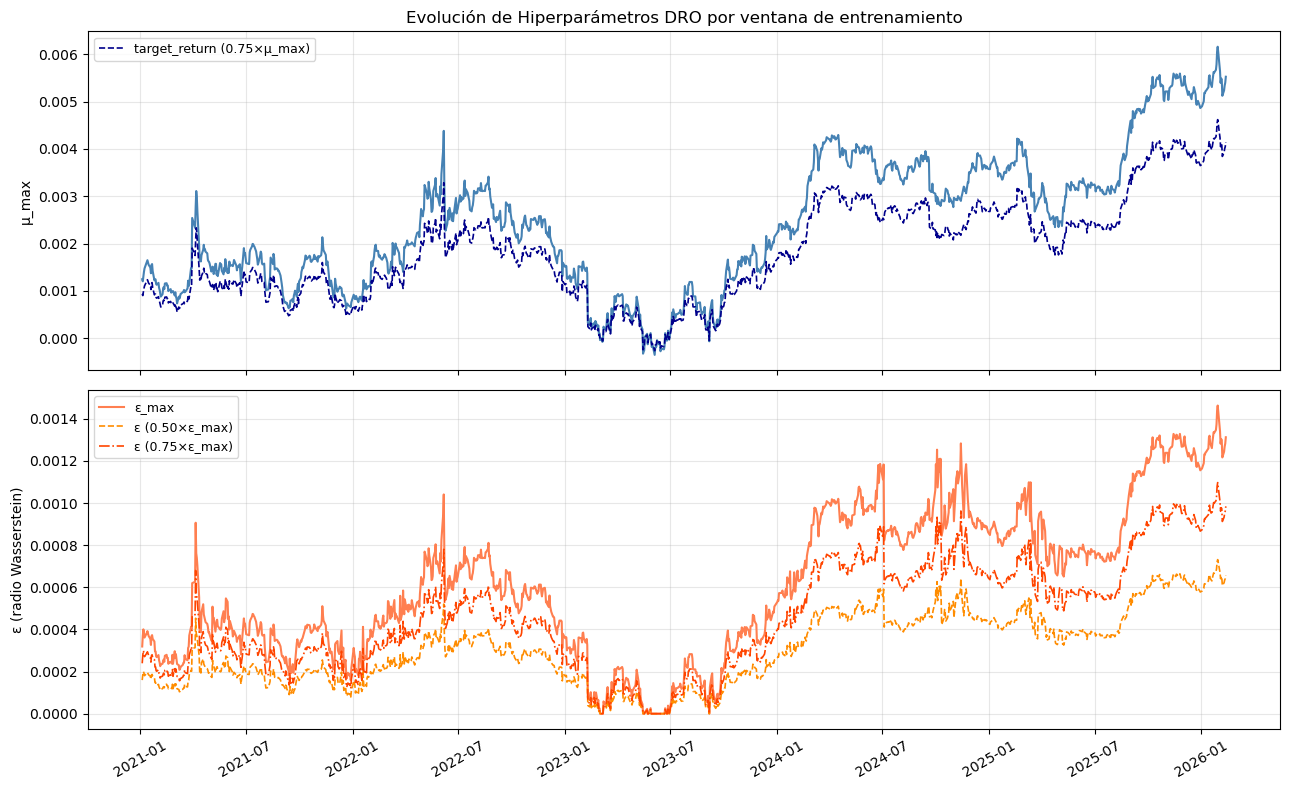

  → Gráfico guardado en c:\Users\emngz\Downloads\Universidad\P.I,\PI 2\dro_results_rolling\1_hyperparams_evolution.png


In [9]:
## ============================================================================
## SECCIÓN 7: HIPERPARÁMETROS DRO — EVOLUCIÓN TEMPORAL
## ============================================================================

# Tomar el modelo DRO como referencia para los hiperparámetros
_ref_eps = EPSILON_FRACTIONS[0]
_ref_eps_2 = EPSILON_FRACTIONS[1] if len(EPSILON_FRACTIONS) > 1 else None
_ref_model = f"2-WDRO-Markowitz (eps={_ref_eps:.2f})"
_ref_entries = [e for e in raw_results.get(_ref_model, [])
                if not np.isnan(e.get('mu_max', np.nan))]

if _ref_entries:
    hyp_dates    = [e['val_start'] for e in _ref_entries]
    mu_max_vals  = [e['mu_max']    for e in _ref_entries]
    eps_max_vals = [e['eps_max']   for e in _ref_entries]
    eps_vals     = [e['epsilon']   for e in _ref_entries]

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

    axes[0].plot(hyp_dates, [v for v in mu_max_vals], color='steelblue', lw=1.5)
    axes[0].set_ylabel('μ_max')
    axes[0].plot(hyp_dates, [v * MU_MAX_FRACTION for v in mu_max_vals], color='darkblue', lw=1.2, ls='--', label=f'target_return ({MU_MAX_FRACTION:.2f}×μ_max)')
    axes[0].legend(fontsize=9)
    axes[0].set_title('Evolución de Hiperparámetros DRO por ventana de entrenamiento')
    axes[0].grid(alpha=0.3)

    axes[1].plot(hyp_dates, eps_max_vals, color='coral', lw=1.5, label='ε_max')
    axes[1].plot(hyp_dates, eps_vals, color='darkorange', lw=1.2, ls='--',
                 label=f'ε ({_ref_eps:.2f}×ε_max)')
    if _ref_eps_2 is not None:  
        eps_vals_2 = [e['epsilon'] for e in raw_results.get(f"2-WDRO-Markowitz (eps={_ref_eps_2:.2f})", [])
                      if not np.isnan(e.get('epsilon', np.nan))]
        if eps_vals_2:
            axes[1].plot(hyp_dates, eps_vals_2, color='orangered', lw=1.2, ls='-.',
                         label=f'ε ({_ref_eps_2:.2f}×ε_max)')
    axes[1].set_ylabel('ε (radio Wasserstein)')
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)


    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "1_hyperparams_evolution.png", dpi=150)
    plt.show()
    print(f"  → Gráfico guardado en {RESULTS_DIR / '1_hyperparams_evolution.png'}")
else:
    print("  No hay entradas con hiperparámetros para graficar.")


---
## Sección 8: Visualizaciones de Rendimiento

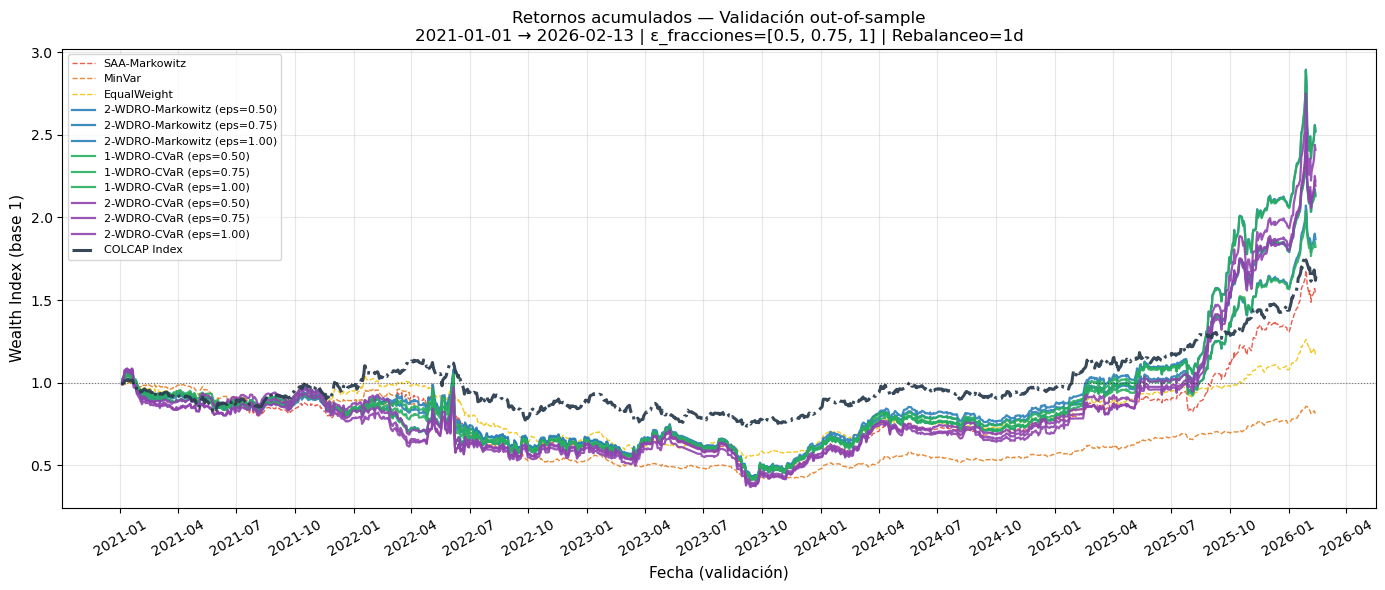

  → Gráfico guardado en c:\Users\emngz\Downloads\Universidad\P.I,\PI 2\dro_results_rolling\2_wealth_index.png


In [10]:
## ============================================================================
## SECCIÓN 8A: RETORNOS ACUMULADOS EN VALIDACIÓN (WEALTH INDEX)
## ============================================================================

# Paleta de colores por modelo base
BASE_COLOR_MAP = {
    'SAA-Markowitz'    : '#e74c3c',
    'MinVar'           : '#e67e22',
    'EqualWeight'      : '#f1c40f',
    '2-WDRO-Markowitz' : '#2980b9',
    '1-WDRO-CVaR'      : '#27ae60',
    '2-WDRO-CVaR'      : '#8e44ad',
    BENCHMARK_LABEL    : '#2c3e50',
}
BASE_LINE_STYLE = {
    'SAA-Markowitz'    : '--',
    'MinVar'           : '--',
    'EqualWeight'      : '--',
    '2-WDRO-Markowitz' : '-',
    '1-WDRO-CVaR'      : '-',
    '2-WDRO-CVaR'      : '-',
    BENCHMARK_LABEL    : '-.',
}

fig, ax = plt.subplots(figsize=(14, 6))

wealth_series = {}  # para uso posterior

for model_name in MODEL_RUN_NAMES:
    entries = raw_results.get(model_name, [])
    ok_entries = [e for e in entries
                  if e['status'] == 'optimal'
                  and not np.any(np.isnan(e['val_returns']))]
    if not ok_entries:
        continue

    # Concatenar retornos: usar val_start de cada entrada como referencia temporal
    all_dates   = []
    all_returns = []
    for e in ok_entries:
        n_days = len(e['val_returns'])
        d_start = e['val_start']
        # generar timestamps internos para cada día de validación
        for k in range(n_days):
            all_dates.append(d_start + pd.Timedelta(days=k))
        all_returns.extend(e['val_returns'].tolist())

    # Wealth index: producto acumulado de (1 + r)
    r_arr    = np.array(all_returns)
    wealth   = np.cumprod(1 + r_arr)
    wealth_series[model_name] = (all_dates[:len(wealth)], wealth)

    base_name = get_base_model_name(model_name)
    ax.plot(all_dates[:len(wealth)], wealth,
            label=model_name,
            color=BASE_COLOR_MAP.get(base_name, 'gray'),
            ls=BASE_LINE_STYLE.get(base_name, '-'),
            lw=1.6 if MODEL_RUN_TYPE.get(model_name) == 'dro' else 1.0,
            alpha=0.9)

# Benchmark externo COLCAP (solo referencia visual)
if 'benchmark_returns_oos' in globals() and len(benchmark_returns_oos) > 0:
    bench_wealth = np.cumprod(1 + benchmark_returns_oos.values)
    wealth_series[BENCHMARK_LABEL] = (benchmark_returns_oos.index, bench_wealth)
    ax.plot(
        benchmark_returns_oos.index,
        bench_wealth,
        label=BENCHMARK_LABEL,
        color=BASE_COLOR_MAP[BENCHMARK_LABEL],
        ls=BASE_LINE_STYLE[BENCHMARK_LABEL],
        lw=2.2,
        alpha=0.95,
    )

ax.axhline(1.0, color='black', ls=':', lw=0.8, alpha=0.5)
ax.set_xlabel("Fecha (validación)", fontsize=11)
ax.set_ylabel("Wealth Index (base 1)", fontsize=11)
ax.set_title(
    f"Retornos acumulados — Validación out-of-sample\n"
    f"{VAL_START_DATE} → {VAL_END_DATE} | "
    f"ε_fracciones={EPSILON_FRACTIONS} | Rebalanceo={REBALANCE_FREQ}d",
    fontsize=12
)
ax.legend(loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.xticks(rotation=30)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "2_wealth_index.png", dpi=150)
plt.show()
print(f"  → Gráfico guardado en {RESULTS_DIR / '2_wealth_index.png'}")


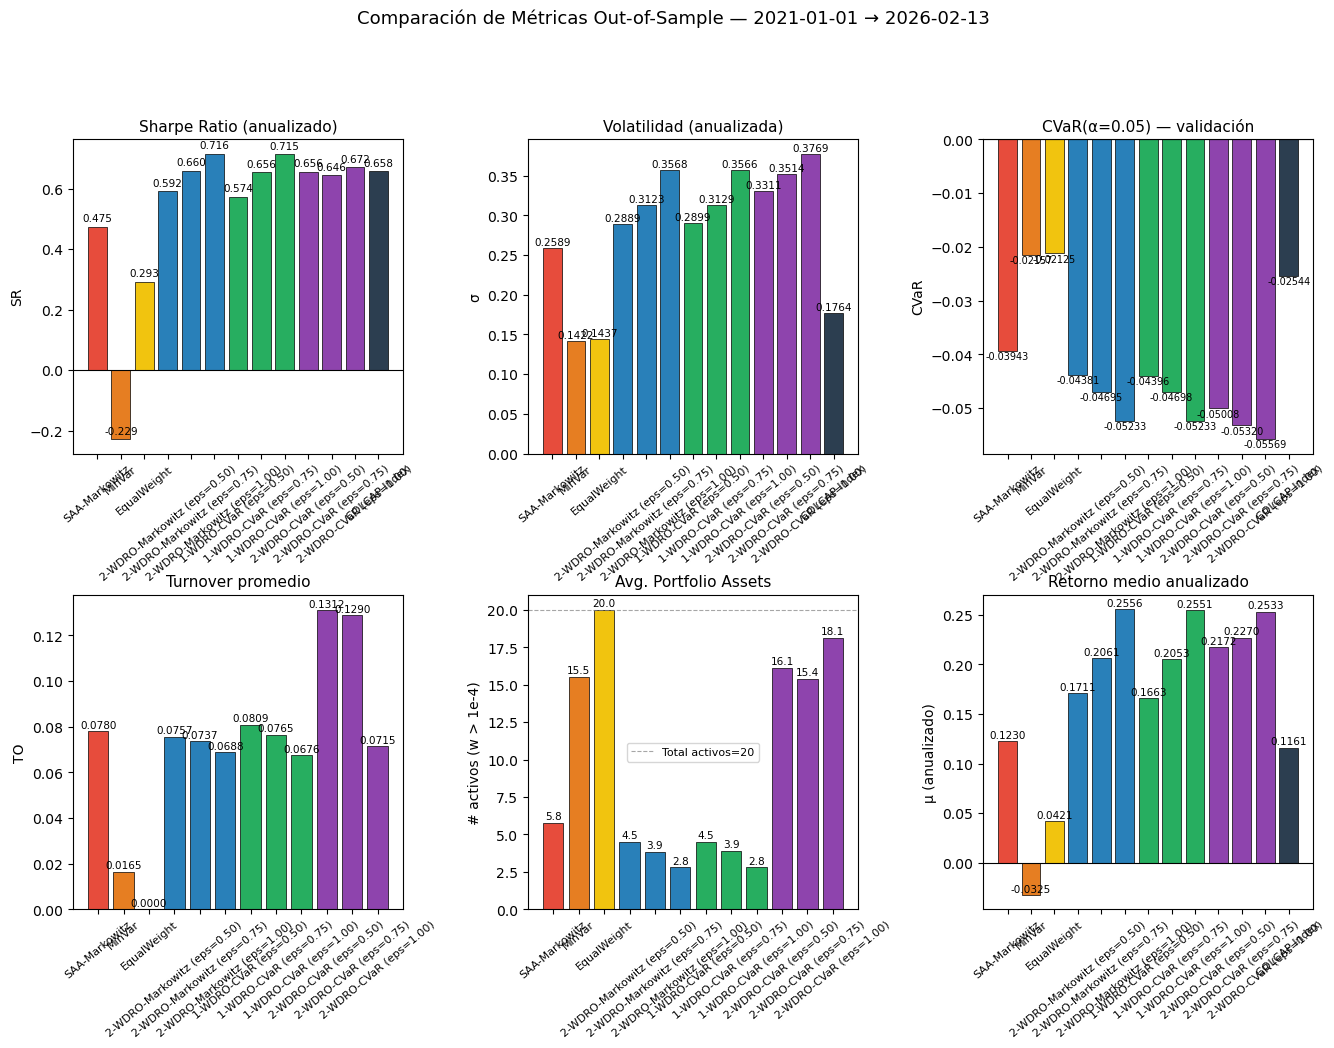

  → Gráfico guardado en c:\Users\emngz\Downloads\Universidad\P.I,\PI 2\dro_results_rolling\3_metrics_panel.png


In [11]:
## ============================================================================
## SECCIÓN 8B: PANEL 2×3 — MÉTRICAS INDIVIDUALES
## ============================================================================

metrics_subset = metrics_df.dropna(subset=['Sharpe (anual)'])
if len(metrics_subset) == 0:
    print("⚠️  No hay métricas disponibles para graficar.")
else:
    model_labels  = metrics_subset.index.tolist()
    colors_bar    = [BASE_COLOR_MAP.get(get_base_model_name(m), 'gray') for m in model_labels]

    fig = plt.figure(figsize=(16, 10))
    gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

    # ── 1. Sharpe anualizado ──────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    vals = metrics_subset['Sharpe (anual)'].values
    bars = ax1.bar(model_labels, vals, color=colors_bar, edgecolor='black', lw=0.5)
    ax1.axhline(0, color='black', lw=0.8)
    ax1.set_title("Sharpe Ratio (anualizado)", fontsize=11)
    ax1.set_ylabel("SR")
    ax1.tick_params(axis='x', rotation=40, labelsize=8)
    for bar, v in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

    # ── 2. Volatilidad (Std) ──────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    vals2 = (metrics_subset['Std'] * np.sqrt(252)).values  # anualizada
    bars2 = ax2.bar(model_labels, vals2, color=colors_bar, edgecolor='black', lw=0.5)
    ax2.set_title("Volatilidad (anualizada)", fontsize=11)
    ax2.set_ylabel("σ")
    ax2.tick_params(axis='x', rotation=40, labelsize=8)
    for bar, v in zip(bars2, vals2):
        ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
                 f'{v:.4f}', ha='center', va='bottom', fontsize=7.5)

    # ── 3. CVaR(0.05) ─────────────────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[0, 2])
    vals3 = metrics_subset['CVaR(0.05)'].values
    bars3 = ax3.bar(model_labels, vals3, color=colors_bar, edgecolor='black', lw=0.5)
    ax3.axhline(0, color='black', lw=0.8)
    ax3.set_title("CVaR(α=0.05) — validación", fontsize=11)
    ax3.set_ylabel("CVaR")
    ax3.tick_params(axis='x', rotation=40, labelsize=8)
    for bar, v in zip(bars3, vals3):
        ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() - 0.0001,
                 f'{v:.5f}', ha='center', va='top', fontsize=7, color='black')

    # ── 4. Turnover ────────────────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 0])
    to_vals = metrics_df['Turnover'].values
    valid_to = ~np.isnan(to_vals)
    bars4 = ax4.bar(
        [l for l, v in zip(metrics_df.index.tolist(), valid_to) if v],
        [v for v in to_vals if not np.isnan(v)],
        color=[BASE_COLOR_MAP.get(get_base_model_name(m), 'gray') for m, v in zip(metrics_df.index.tolist(), valid_to) if v],
        edgecolor='black', lw=0.5
    )
    ax4.set_title("Turnover promedio", fontsize=11)
    ax4.set_ylabel("TO")
    ax4.tick_params(axis='x', rotation=40, labelsize=8)
    for bar, v in zip(bars4, [v for v in to_vals if not np.isnan(v)]):
        ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.0005,
                 f'{v:.4f}', ha='center', va='bottom', fontsize=7.5)

    # ── 5. Avg. Portfolio Assets ───────────────────────────────────────────────
    ax5 = fig.add_subplot(gs[1, 1])
    avg_assets = metrics_df['Avg. Portfolio Assets'].values
    bars5 = ax5.bar(metrics_df.index.tolist(), avg_assets,
                    color=[BASE_COLOR_MAP.get(get_base_model_name(m), 'gray') for m in metrics_df.index.tolist()],
                    edgecolor='black', lw=0.5)
    ax5.axhline(m, color='gray', ls='--', lw=0.8, alpha=0.7, label=f'Total activos={m}')
    ax5.set_title("Avg. Portfolio Assets", fontsize=11)
    ax5.set_ylabel("# activos (w > 1e-4)")
    ax5.tick_params(axis='x', rotation=40, labelsize=8)
    ax5.legend(fontsize=8)
    for bar, v in zip(bars5, avg_assets):
        if not np.isnan(v):
            ax5.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                     f'{v:.1f}', ha='center', va='bottom', fontsize=7.5)

    # ── 6. Retorno medio ───────────────────────────────────────────────────────
    ax6 = fig.add_subplot(gs[1, 2])
    mean_vals = (metrics_df['Media'] * 252).values  # anualizado
    bars6 = ax6.bar(metrics_df.index.tolist(), mean_vals,
                    color=[BASE_COLOR_MAP.get(get_base_model_name(m), 'gray') for m in metrics_df.index.tolist()],
                    edgecolor='black', lw=0.5)
    ax6.axhline(0, color='black', lw=0.8)
    ax6.set_title("Retorno medio anualizado", fontsize=11)
    ax6.set_ylabel("μ (anualizado)")
    ax6.tick_params(axis='x', rotation=40, labelsize=8)
    for bar, v in zip(bars6, mean_vals):
        ax6.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
                 f'{v:.4f}', ha='center', va='bottom', fontsize=7.5)

    fig.suptitle(
        f"Comparación de Métricas Out-of-Sample — {VAL_START_DATE} → {VAL_END_DATE}",
        fontsize=13, y=1.01
    )
    plt.savefig(RESULTS_DIR / "3_metrics_panel.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  → Gráfico guardado en {RESULTS_DIR / '3_metrics_panel.png'}")

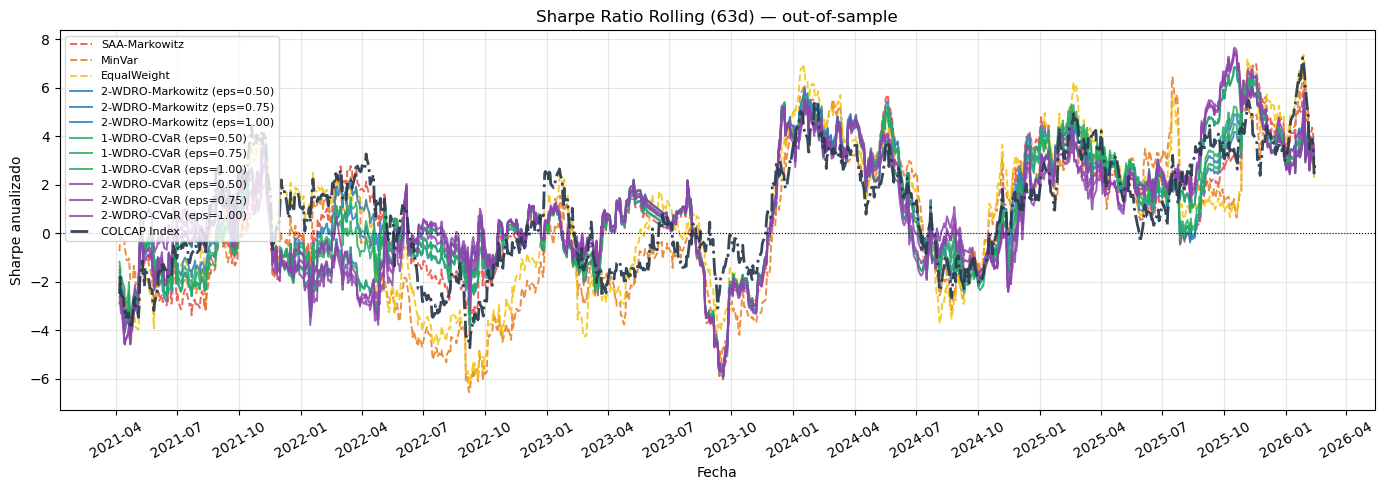

  → Gráfico guardado en c:\Users\emngz\Downloads\Universidad\P.I,\PI 2\dro_results_rolling\4_rolling_sharpe.png


In [12]:
## ============================================================================
## SECCIÓN 8C: EVOLUCIÓN TEMPORAL DEL SHARPE RATIO (ROLLING 63 DÍAS)
## ============================================================================

fig, ax = plt.subplots(figsize=(14, 5))
ROLLING_SR_WIN = 63  # ventana para Sharpe rolling (~1 trimestre)

for model_name in MODEL_RUN_NAMES:
    entries = raw_results.get(model_name, [])
    ok_entries = [e for e in entries
                  if e['status'] == 'optimal'
                  and not np.any(np.isnan(e['val_returns']))]
    if not ok_entries:
        continue

    all_dates   = []
    all_returns = []
    for e in ok_entries:
        for k, r in enumerate(e['val_returns']):
            all_dates.append(e['val_start'] + pd.Timedelta(days=k))
            all_returns.append(r)

    if len(all_returns) < ROLLING_SR_WIN:
        continue

    r_s = pd.Series(all_returns, index=pd.DatetimeIndex(all_dates))
    rolling_mean = r_s.rolling(ROLLING_SR_WIN).mean()
    rolling_std  = r_s.rolling(ROLLING_SR_WIN).std()
    rolling_sr   = (rolling_mean / rolling_std) * np.sqrt(252)

    base_name = get_base_model_name(model_name)
    ax.plot(rolling_sr.index, rolling_sr.values,
            label=model_name,
            color=BASE_COLOR_MAP.get(base_name, 'gray'),
            ls=BASE_LINE_STYLE.get(base_name, '-'),
            lw=1.4, alpha=0.85)

# Benchmark externo COLCAP (solo referencia visual)
if 'benchmark_returns_oos' in globals() and len(benchmark_returns_oos) >= ROLLING_SR_WIN:
    bench_s = pd.Series(benchmark_returns_oos.values, index=benchmark_returns_oos.index)
    bench_roll_mean = bench_s.rolling(ROLLING_SR_WIN).mean()
    bench_roll_std  = bench_s.rolling(ROLLING_SR_WIN).std()
    bench_roll_sr   = (bench_roll_mean / bench_roll_std) * np.sqrt(252)

    ax.plot(
        bench_roll_sr.index,
        bench_roll_sr.values,
        label=BENCHMARK_LABEL,
        color=BASE_COLOR_MAP.get(BENCHMARK_LABEL, 'black'),
        ls=BASE_LINE_STYLE.get(BENCHMARK_LABEL, '-.'),
        lw=2.0,
        alpha=0.95,
    )

ax.axhline(0, color='black', lw=0.8, ls=':')
ax.set_title(f"Sharpe Ratio Rolling ({ROLLING_SR_WIN}d) — out-of-sample", fontsize=12)
ax.set_xlabel("Fecha")
ax.set_ylabel("Sharpe anualizado")
ax.legend(loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.xticks(rotation=30)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "4_rolling_sharpe.png", dpi=150)
plt.show()
print(f"  → Gráfico guardado en {RESULTS_DIR / '4_rolling_sharpe.png'}")

In [13]:
## ============================================================================
## SECCIÓN 8D: COMPOSICIÓN PROMEDIO DE LOS PORTAFOLIOS (TABLA UNIFICADA)
## ============================================================================

# Separar modelos en benchmarks y DRO
benchmark_models = [m for m in MODEL_RUN_NAMES if MODEL_RUN_TYPE.get(m) == 'benchmark']
dro_base_models = list(set(get_base_model_name(m) for m in MODEL_RUN_NAMES if MODEL_RUN_TYPE.get(m) == 'dro'))

# Función auxiliar para extraer composición de un modelo
def get_portfolio_composition(model_name, raw_results, tickers, n_top=5):
    entries = raw_results.get(model_name, [])
    ok_entries = [e for e in entries
                  if e['status'] == 'optimal'
                  and not np.any(np.isnan(e['weights']))]
    if not ok_entries:
        return None
    
    weights_mat = np.array([e['weights'] for e in ok_entries])
    avg_weights = np.mean(weights_mat, axis=0)
    
    order = np.argsort(avg_weights)[::-1]
    top_indices = order[:n_top]
    
    return [(tickers[i], avg_weights[i]) for i in top_indices if avg_weights[i] > ASSETS_THRESHOLD]

# Recopilar datos para todos los modelos
all_models = benchmark_models + [m for m in MODEL_RUN_NAMES if MODEL_RUN_TYPE.get(m) == 'dro']
table_data = []

for model_name in all_models:
    composition = get_portfolio_composition(model_name, raw_results, tickers, n_top=5)
    if composition:
        for rank, (ticker, weight) in enumerate(composition, 1):
            table_data.append({
                'Modelo': model_name,
                'Ranking': rank,
                'Empresa': ticker,
                'Peso Promedio': f"{weight:.4f}"
            })

# Crear tabla
df_composition = pd.DataFrame(table_data)
df_pivot = df_composition.pivot_table(
    index='Empresa',
    columns='Modelo',
    values='Peso Promedio',
    aggfunc='first'
)

print("\n" + "="*80)
print("COMPOSICIÓN PROMEDIO DE PORTAFOLIOS")
print("="*80)
print(df_pivot.to_string())

# Guardar tabla
df_pivot.to_csv(RESULTS_DIR / "5_portfolio_composition_table.csv")
print(f"\n  → Tabla guardada en {RESULTS_DIR / '5_portfolio_composition_table.csv'}")



COMPOSICIÓN PROMEDIO DE PORTAFOLIOS
Modelo                                 1-WDRO-CVaR (eps=0.50) 1-WDRO-CVaR (eps=0.75) 1-WDRO-CVaR (eps=1.00) 2-WDRO-CVaR (eps=0.50) 2-WDRO-CVaR (eps=0.75) 2-WDRO-CVaR (eps=1.00) 2-WDRO-Markowitz (eps=0.50) 2-WDRO-Markowitz (eps=0.75) 2-WDRO-Markowitz (eps=1.00) EqualWeight  MinVar SAA-Markowitz
Empresa                                                                                                                                                                                                                                                                                               
Almacenes Exito                                        0.0574                 0.0491                    NaN                 0.0432                 0.0398                    NaN                         NaN                         NaN                         NaN         NaN  0.0824           NaN
Aval Acciones y Valores Pref                              NaN                 

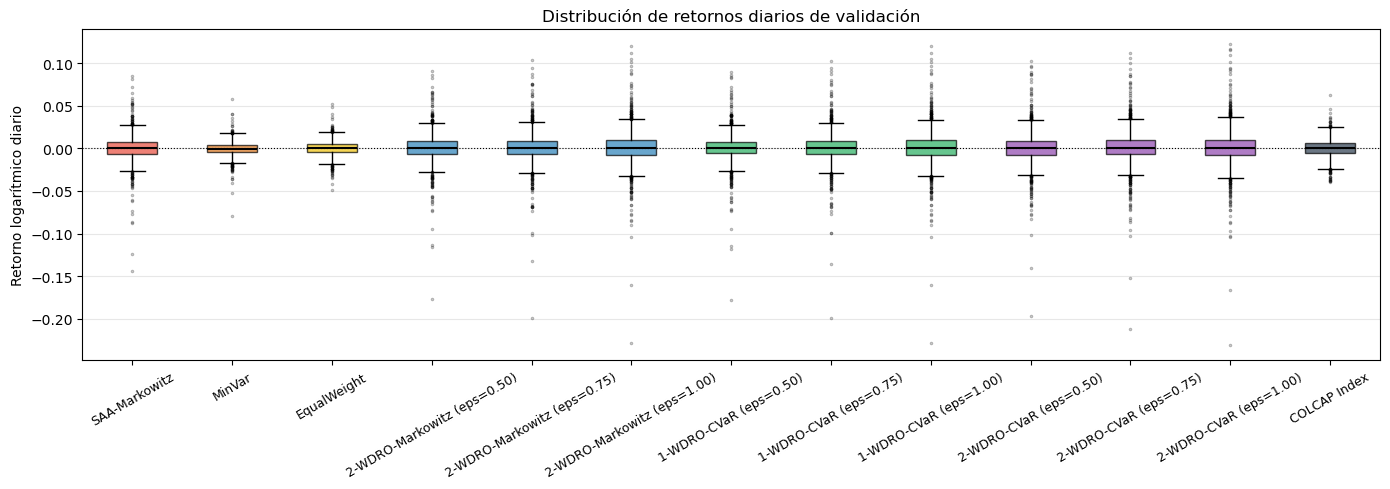

  → Gráfico guardado en c:\Users\emngz\Downloads\Universidad\P.I,\PI 2\dro_results_rolling\6_returns_distribution.png


In [14]:
## ============================================================================
## SECCIÓN 8E: DISTRIBUCIÓN DE RETORNOS DE VALIDACIÓN (BOX PLOTS)
## ============================================================================

fig, ax = plt.subplots(figsize=(14, 5))

box_data   = []
box_labels = []

for model_name in MODEL_RUN_NAMES:
    entries = raw_results.get(model_name, [])
    ok_entries = [e for e in entries
                  if e['status'] == 'optimal'
                  and not np.any(np.isnan(e['val_returns']))]
    if not ok_entries:
        continue
    all_ret = np.concatenate([e['val_returns'] for e in ok_entries])
    box_data.append(all_ret)
    box_labels.append(model_name)

# Benchmark externo COLCAP (solo referencia visual)
if 'benchmark_returns_oos' in globals() and len(benchmark_returns_oos) > 0:
    box_data.append(benchmark_returns_oos.values)
    box_labels.append(BENCHMARK_LABEL)

bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
                medianprops=dict(color='black', linewidth=1.5),
                flierprops=dict(marker='.', alpha=0.3, markersize=3),
                showfliers=True)

for patch, model_name in zip(bp['boxes'], box_labels):
    patch.set_facecolor(BASE_COLOR_MAP.get(get_base_model_name(model_name), 'gray'))
    patch.set_alpha(0.7)

ax.axhline(0, color='black', lw=0.8, ls=':')
ax.set_title("Distribución de retornos diarios de validación", fontsize=12)
ax.set_ylabel("Retorno logarítmico diario")
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "6_returns_distribution.png", dpi=150)
plt.show()
print(f"  → Gráfico guardado en {RESULTS_DIR / '6_returns_distribution.png'}")

---
## Sección 9: Tabla Resumen Final y Exportación de Resultados

In [15]:
## ============================================================================
## SECCIÓN 9A: TABLA RESUMEN FINAL
## ============================================================================

# Construir tabla extendida incluyendo métricas anualizadas
summary_rows = []
for model_name in MODEL_RUN_NAMES:
    if model_name not in metrics_df.index:
        continue
    row = metrics_df.loc[model_name]
    summary_rows.append({
        'Modelo'               : model_name,
        'Tipo'                 : MODEL_RUN_TYPE.get(model_name, 'unknown').upper(),
        'Epsilon frac'         : MODEL_RUN_EPS.get(model_name, np.nan),
        'Media (diaria)'       : row['Media'],
        'Media (anual)'        : row['Media'] * 252,
        'Std (diaria)'         : row['Std'],
        'Std (anual)'          : row['Std'] * np.sqrt(252),
        'Sharpe (diario)'      : row['Sharpe (diario)'],
        'Sharpe (anual)'       : row['Sharpe (anual)'],
        'CVaR(0.05)'           : row['CVaR(0.05)'],
        'Turnover promedio'    : row['Turnover'],
        'Avg. Portfolio Assets': row['Avg. Portfolio Assets'],
        'N iter. OK'           : row['N iteraciones OK'],
    })

summary_df = pd.DataFrame(summary_rows).set_index('Modelo')

print("\n" + "="*100)
print("  TABLA COMPARATIVA FINAL — MÉTRICAS OUT-OF-SAMPLE")
print(f"  Período de validación: {VAL_START_DATE} → {VAL_END_DATE}")
print(f"  ε_fracciones = {EPSILON_FRACTIONS}")
print(f"  α = {CVAR_CONFIDENCE} | Rebalanceo = {REBALANCE_FREQ} días | Ventana = {WINDOW_SIZE_DAYS} días")
print("="*100)

display(
    summary_df.style
    .format({
        'Epsilon frac'         : '{:.2f}',
        'Media (diaria)'       : '{:.7f}',
        'Media (anual)'        : '{:.5f}',
        'Std (diaria)'         : '{:.7f}',
        'Std (anual)'          : '{:.5f}',
        'Sharpe (diario)'      : '{:.4f}',
        'Sharpe (anual)'       : '{:.4f}',
        'CVaR(0.05)'           : '{:.6f}',
        'Turnover promedio'    : '{:.4f}',
        'Avg. Portfolio Assets': '{:.2f}',
        'N iter. OK'           : '{:.2f}',
    }, na_rep='—')
    .highlight_max(subset=['Sharpe (anual)', 'Media (anual)'], color='#c6efce')
    .highlight_min(subset=['CVaR(0.05)', 'Std (anual)', 'Turnover promedio'], color='#c6efce')
    .set_caption("Verde = mejor valor en cada métrica")
)

# Guardar CSV
summary_df.to_csv(RESULTS_DIR / "summary_final.csv")
print(f"\n✓ Tabla guardada en {RESULTS_DIR / 'summary_final.csv'}")


  TABLA COMPARATIVA FINAL — MÉTRICAS OUT-OF-SAMPLE
  Período de validación: 2021-01-01 → 2026-02-13
  ε_fracciones = [0.5, 0.75, 1]
  α = 0.05 | Rebalanceo = 1 días | Ventana = 252 días


,Tipo,Epsilon frac,Media (diaria),Media (anual),Std (diaria),Std (anual),Sharpe (diario),Sharpe (anual),CVaR(0.05),Turnover promedio,Avg. Portfolio Assets,N iter. OK
Modelo,,,,,,,,,,,,
SAA-Markowitz,BENCHMARK,—,0.0004879,0.12295,0.0163119,0.25894,0.0299,0.4748,-0.039429,0.0780,5.77,1222.00
MinVar,BENCHMARK,—,-0.0001291,-0.03253,0.0089583,0.14221,-0.0144,-0.2288,-0.021570,0.0165,15.51,1250.00
EqualWeight,BENCHMARK,—,0.0001670,0.04208,0.0090512,0.14368,0.0185,0.2929,-0.021254,0.0000,20.00,1250.00
2-WDRO-Markowitz (eps=0.50),DRO,0.50,0.0006791,0.17113,0.0181972,0.28887,0.0373,0.5924,-0.043807,0.0757,4.50,1222.00
2-WDRO-Markowitz (eps=0.75),DRO,0.75,0.0008177,0.20606,0.0196743,0.31232,0.0416,0.6598,-0.046955,0.0737,3.85,1222.00
2-WDRO-Markowitz (eps=1.00),DRO,1.00,0.0010144,0.25563,0.0224786,0.35684,0.0451,0.7164,-0.052330,0.0688,2.80,1222.00
1-WDRO-CVaR (eps=0.50),DRO,0.50,0.0006598,0.16627,0.0182633,0.28992,0.0361,0.5735,-0.043957,0.0809,4.48,1222.00
1-WDRO-CVaR (eps=0.75),DRO,0.75,0.0008145,0.20525,0.0197107,0.31290,0.0413,0.6560,-0.046981,0.0765,3.92,1222.00
1-WDRO-CVaR (eps=1.00),DRO,1.00,0.0010123,0.25510,0.0224637,0.35660,0.0451,0.7154,-0.052327,0.0676,2.80,1222.00



✓ Tabla guardada en c:\Users\emngz\Downloads\Universidad\P.I,\PI 2\dro_results_rolling\summary_final.csv


In [16]:
## ============================================================================
## SECCIÓN 9B: EXPORTAR RESULTADOS DETALLADOS
## ============================================================================

# ── Series de retornos por modelo ─────────────────────────────────────────────
all_series = {}
for model_name in MODEL_RUN_NAMES:
    entries = raw_results.get(model_name, [])
    rows_export = []
    for e in entries:
        for k, r in enumerate(e['val_returns']):
            rows_export.append({
                'model'      : model_name,
                'step'       : e['step'],
                'date'       : e['val_start'] + pd.Timedelta(days=k),
                'ret'        : r,
                'mu_max'     : e['mu_max'],
                'eps_max'    : e['eps_max'],
                'epsilon'    : e['epsilon'],
                'epsilon_fraction': e.get('epsilon_fraction', MODEL_RUN_EPS.get(model_name, np.nan)),
                'status'     : e['status'],
                'status_code': e.get('status_code', -1),
                'status_description': e.get('status_description', 'N/A'),
            })
    if rows_export:
        all_series[model_name] = pd.DataFrame(rows_export)

# Guardar series de retornos
for model_name, df_s in all_series.items():
    safe_name = model_name.replace(' ', '_').replace('-', '_').replace('=', '')
    fpath = RESULTS_DIR / f"returns_{safe_name}.csv"
    df_s.to_csv(fpath, index=False)

# ── Historial de pesos por iteración ──────────────────────────────────────────
weights_records = []
for model_name in MODEL_RUN_NAMES:
    entries = raw_results.get(model_name, [])
    for e in entries:
        if e['status'] == 'optimal' and not np.any(np.isnan(e['weights'])):
            row = {
                'model'    : model_name,
                'step'     : e['step'],
                'val_start': e['val_start'],
                'mu_max'   : e['mu_max'],
                'eps_max'  : e['eps_max'],
                'epsilon'  : e['epsilon'],
                'epsilon_fraction': e.get('epsilon_fraction', MODEL_RUN_EPS.get(model_name, np.nan)),
            }
            for i, t in enumerate(tickers):
                row[f'w_{t[:15]}'] = e['weights'][i]
            weights_records.append(row)

if weights_records:
    weights_df = pd.DataFrame(weights_records)
    weights_df.to_csv(RESULTS_DIR / "weights_history.csv", index=False)
    print(f"✓ Historial de pesos guardado en {RESULTS_DIR / 'weights_history.csv'}")
    print(f"  Shape: {weights_df.shape}")

# ── Reporte detallado de errores por modelo ────────────────────────────────────
error_report = []
for model_name in MODEL_RUN_NAMES:
    entries = raw_results.get(model_name, [])
    non_optimal = [e for e in entries if e['status'] != 'optimal']
    if non_optimal:
        for e in non_optimal:
            error_report.append({
                'model': model_name,
                'step': e['step'],
                'val_start': e['val_start'],
                'status': e['status'],
                'status_code': e.get('status_code', -1),
                'status_description': e.get('status_description', 'desconocido'),
            })

if error_report:
    error_df = pd.DataFrame(error_report)
    error_df.to_csv(RESULTS_DIR / "error_log.csv", index=False)
    print(f"✓ Reporte de errores guardado en {RESULTS_DIR / 'error_log.csv'}")
    print(f"  Total de errores: {len(error_df)}")

print(f"\n✓ Series de retornos guardadas en {RESULTS_DIR}/returns_*.csv")
print(f"\n📁 Todos los resultados en: {RESULTS_DIR}")
print(f"   Archivos generados:")
for f in sorted(RESULTS_DIR.glob("*.csv")) :
    print(f"   - {f.name}")
for f in sorted(RESULTS_DIR.glob("*.png")):
    print(f"   - {f.name}")

✓ Historial de pesos guardado en c:\Users\emngz\Downloads\Universidad\P.I,\PI 2\dro_results_rolling\weights_history.csv
  Shape: (14720, 27)
✓ Reporte de errores guardado en c:\Users\emngz\Downloads\Universidad\P.I,\PI 2\dro_results_rolling\error_log.csv
  Total de errores: 280

✓ Series de retornos guardadas en c:\Users\emngz\Downloads\Universidad\P.I,\PI 2\dro_results_rolling/returns_*.csv

📁 Todos los resultados en: c:\Users\emngz\Downloads\Universidad\P.I,\PI 2\dro_results_rolling
   Archivos generados:
   - 5_portfolio_composition_table.csv
   - error_log.csv
   - metrics_validation.csv
   - returns_1_WDRO_CVaR_(eps0.50).csv
   - returns_1_WDRO_CVaR_(eps0.75).csv
   - returns_1_WDRO_CVaR_(eps1.00).csv
   - returns_2_WDRO_CVaR_(eps0.50).csv
   - returns_2_WDRO_CVaR_(eps0.75).csv
   - returns_2_WDRO_CVaR_(eps1.00).csv
   - returns_2_WDRO_Markowitz_(eps0.50).csv
   - returns_2_WDRO_Markowitz_(eps0.75).csv
   - returns_2_WDRO_Markowitz_(eps1.00).csv
   - returns_EqualWeight.csv
   - r

---
## Sección 10: Resumen Teórico y Formulación Matemática

### Formulaciones SOCP de los modelos DRO

#### A. 2-WDRO-Markowitz

$$\min_{w, t, r} \; t + \varepsilon r$$

$$\text{s.t.} \quad \|\hat{\Sigma}^{1/2} w\|_2 \leq t, \quad \|w\|_2 \leq r, \quad \hat{m}^\top w - \varepsilon \|w\|_2 \geq \mu$$

$$\sum_i w_i = 1, \quad w_i \geq 0$$

#### B. 1-WDRO-CVaR (Corolario 1, dualidad Kantorovich-Rubinstein)

$$\min_{w, \tau, \lambda, s} \; \lambda \varepsilon + \frac{1}{N}\sum_{i=1}^N s_i$$

$$\text{s.t.} \quad a_k \langle w, \xi_i \rangle + b_k \tau \leq s_i \quad \forall i, k \in \{1,2\}$$

$$|a_k| \|w\|_2 \leq \lambda, \quad \frac{1}{N}\sum_i \langle w, \xi_i \rangle - \varepsilon \|w\|_2 \geq \mu$$

donde $a_1 = -1/\alpha$, $b_1 = 1 - 1/\alpha$, $a_2 = 0$, $b_2 = 1$.

#### C. 2-WDRO-CVaR (Teorema 1, p=2)

$$\min_{w, \tau, \lambda, s, z} \; \lambda \varepsilon^2 + \frac{1}{N}\sum_{i=1}^N s_i$$

$$\text{s.t.} \quad \frac{a_k^2}{4} z + a_k \langle w, \xi_i \rangle + b_k \tau \leq s_i, \quad \left\|\begin{pmatrix} 2w \\ \lambda - z \end{pmatrix}\right\|_2 \leq \lambda + z$$

### Radio de Wasserstein — Selección automática por ventana

En cada iteración del rolling window, el radio se calibra con:

$$\varepsilon = \text{fracción} \times \varepsilon_{\max}, \quad \varepsilon_{\max} = \left\|(\hat{m} - \mu \cdot \mathbf{1})_+\right\|_2 \times 0.95$$

$$\mu = 0.30 \times \mu_{\max}, \quad \mu_{\max} = \max_{w \in \Delta^m} \hat{m}^\top w = \max_i \hat{m}_i$$

### Comparación robustez vs. rendimiento

| Modelo | In-sample | Out-of-sample | Robustez | Complejidad |
|---|---|---|---|---|
| SAA-Markowitz | Bueno | Pobre | Baja | Baja |
| MinVar | Bueno | Regular | Media | Baja |
| EqualWeight | Regular | Regular | Alta | Nula |
| **2-WDRO-Markowitz** | Regular | **Excelente** | **Alta** | Media |
| **1-WDRO-CVaR** | Regular | **Excelente** | **Muy alta** | Media |
| **2-WDRO-CVaR** | Regular | **Excelente** | **Muy alta** | Media |

> Los métodos DRO muestran un efecto de regularización (peor in-sample) que se traduce en mejor rendimiento out-of-sample al prevenir el sobreajuste a las realizaciones del mercado COLCAP.

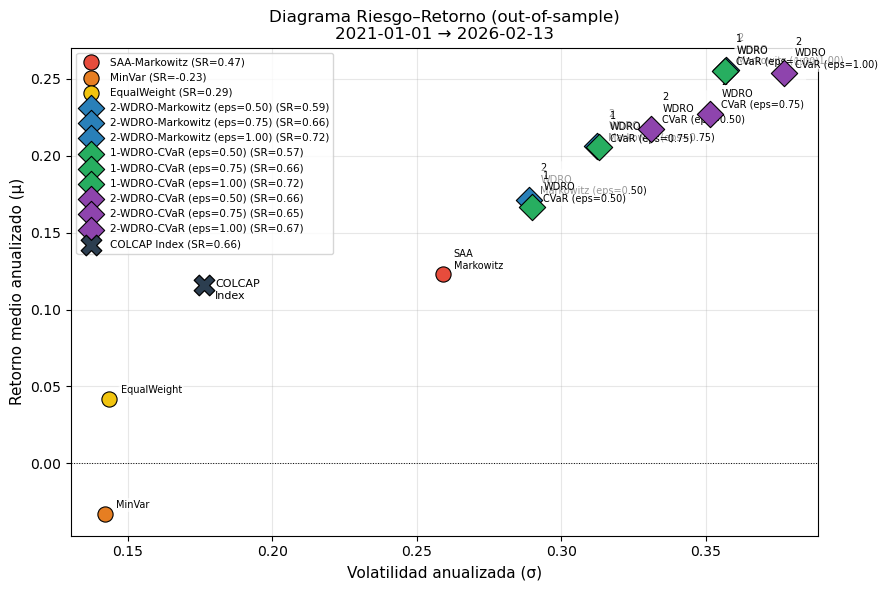

  → Gráfico guardado en c:\Users\emngz\Downloads\Universidad\P.I,\PI 2\dro_results_rolling\7_risk_return_scatter.png

  BACKTEST COMPLETADO ✅
  Período validación : 2021-01-01 → 2026-02-13
  Ventana entrena.   : 252 días | Rebalanceo: 1 días
  ε_fracciones       : [0.5, 0.75, 1] (dinámico por iteración)
  Resultados en      : c:\Users\emngz\Downloads\Universidad\P.I,\PI 2\dro_results_rolling


In [17]:
## ============================================================================
## SECCIÓN 10: GRÁFICO FINAL — RIESGO-RETORNO SCATTER
## ============================================================================

fig, ax = plt.subplots(figsize=(9, 6))

for model_name in MODEL_RUN_NAMES:
    if model_name not in metrics_df.index:
        continue
    row = metrics_df.loc[model_name]
    if pd.isna(row['Media']) or pd.isna(row['Std']):
        continue

    std_ann  = row['Std']  * np.sqrt(252)
    mean_ann = row['Media'] * 252
    sr_ann   = row['Sharpe (anual)']

    is_dro = (MODEL_RUN_TYPE.get(model_name) == 'dro')
    marker = 'D' if is_dro else 'o'
    sz     = 180 if is_dro else 120

    base_name = get_base_model_name(model_name)
    ax.scatter(std_ann, mean_ann,
               color=BASE_COLOR_MAP.get(base_name, 'gray'),
               marker=marker, s=sz, zorder=5,
               edgecolors='black', linewidth=0.8,
               label=f"{model_name} (SR={sr_ann:.2f})")

    ax.annotate(model_name.replace('-', '\n'),
                (std_ann, mean_ann),
                textcoords="offset points",
                xytext=(8, 4), fontsize=7.0,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6, edgecolor='none'))

# Benchmark externo COLCAP (solo referencia visual)
if BENCHMARK_LABEL in metrics_df.index:
    b_row = metrics_df.loc[BENCHMARK_LABEL]
    if not pd.isna(b_row['Media']) and not pd.isna(b_row['Std']):
        b_std_ann = b_row['Std'] * np.sqrt(252)
        b_mean_ann = b_row['Media'] * 252
        b_sr_ann = b_row['Sharpe (anual)']

        ax.scatter(
            b_std_ann,
            b_mean_ann,
            color=BASE_COLOR_MAP.get(BENCHMARK_LABEL, '#2c3e50'),
            marker='X',
            s=220,
            zorder=6,
            edgecolors='black',
            linewidth=0.9,
            label=f"{BENCHMARK_LABEL} (SR={b_sr_ann:.2f})",
        )

        ax.annotate(
            BENCHMARK_LABEL.replace(' ', '\n'),
            (b_std_ann, b_mean_ann),
            textcoords="offset points",
            xytext=(8, -10),
            fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'),
        )

ax.set_xlabel("Volatilidad anualizada (σ)", fontsize=11)
ax.set_ylabel("Retorno medio anualizado (μ)", fontsize=11)
ax.set_title(
    f"Diagrama Riesgo–Retorno (out-of-sample)\n"
    f"{VAL_START_DATE} → {VAL_END_DATE}",
    fontsize=12
)
ax.axhline(0, color='black', lw=0.7, ls=':')
ax.legend(loc='upper left', fontsize=7.5, framealpha=0.8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "7_risk_return_scatter.png", dpi=150)
plt.show()
print(f"  → Gráfico guardado en {RESULTS_DIR / '7_risk_return_scatter.png'}")

print("\n" + "="*70)
print("  BACKTEST COMPLETADO ✅")
print("="*70)
print(f"  Período validación : {VAL_START_DATE} → {VAL_END_DATE}")
print(f"  Ventana entrena.   : {WINDOW_SIZE_DAYS} días | Rebalanceo: {REBALANCE_FREQ} días")
print(f"  ε_fracciones       : {EPSILON_FRACTIONS} (dinámico por iteración)")
print(f"  Resultados en      : {RESULTS_DIR}")
print("="*70)